In [1]:
import os
import math
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading all datasets
df_features = pd.read_csv("/Users/hemanthkumarkottapalli/Desktop/Capstone/features.csv")
df_store = pd.read_csv("/Users/hemanthkumarkottapalli/Desktop/Capstone/stores.csv")
df_train = pd.read_csv("/Users/hemanthkumarkottapalli/Desktop/Capstone/train.csv")
df_test = pd.read_csv("/Users/hemanthkumarkottapalli/Desktop/Capstone/test.csv")

In [3]:
pd.options.display.max_rows=100
pd.pandas.set_option('display.max_columns', None)

Dataset Description
Features.csv: Additional data related to the store, department, and regional activity for the given dates.
train.csv: This is the historical training data, which covers 2010–02–05 to 2012-08-17.
test.csv: Similar to train.csv, we've to predict weekly sales.
stores.csv: Contains anonymized information about the 45 stores, indicating the type and size of the store.

In [4]:
# lowercase all the column names and replace spaces with _
df_train.columns = df_train.columns.str.lower().str.replace(' ', '_')
df_store.columns = df_store.columns.str.lower().str.replace(' ', '_')
df_features.columns = df_features.columns.str.lower().str.replace(' ', '_')

In [5]:
print("Shape of dataset (rows x columns): ", df_features.shape)

Shape of dataset (rows x columns):  (8190, 12)


In [6]:
# Print column names to ensure 'store' and 'date' exist in the test dataset
print("Columns in df_test:", df_test.columns)
print("Columns in df_features:", df_features.columns)
print("Columns in df_store:", df_store.columns)

# Rename columns if necessary to match for merging
df_test.columns = df_test.columns.str.lower()  # Ensure all column names are lowercase
df_test.rename(columns={'store_column_name_here': 'store', 'date_column_name_here': 'date'}, inplace=True)

# Confirm changes
print("Updated columns in df_test:", df_test.columns)


Columns in df_test: Index(['Store', 'Dept', 'Date', 'IsHoliday'], dtype='object')
Columns in df_features: Index(['store', 'date', 'temperature', 'fuel_price', 'markdown1', 'markdown2',
       'markdown3', 'markdown4', 'markdown5', 'cpi', 'unemployment',
       'isholiday'],
      dtype='object')
Columns in df_store: Index(['store', 'type', 'size'], dtype='object')
Updated columns in df_test: Index(['store', 'dept', 'date', 'isholiday'], dtype='object')


In [7]:
# Merge the train dataset with features and store data
df_train_merged = pd.merge(df_train, df_features, on=['store', 'date'], how='left')
df_train_merged = pd.merge(df_train_merged, df_store, on='store', how='left')

# Merge the test dataset with features and store data
df_test_merged = pd.merge(df_test, df_features, on=['store', 'date'], how='left')
df_test_merged = pd.merge(df_test_merged, df_store, on='store', how='left')

# Display the shape and a preview of the merged datasets
print("Shape of merged train dataset: ", df_train_merged.shape)
print("Shape of merged test dataset: ", df_test_merged.shape)
df_train_merged.head()
df_test_merged.head()



Shape of merged train dataset:  (421570, 17)
Shape of merged test dataset:  (115064, 16)


,store,dept,date,isholiday_x,temperature,fuel_price,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment,isholiday_y,type,size
0,1,1,2012-11-02,False,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573,False,A,151315
1,1,1,2012-11-09,False,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573,False,A,151315
2,1,1,2012-11-16,False,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573,False,A,151315
3,1,1,2012-11-23,True,56.23,3.211,883.59,4.17,74910.32,209.91,303.32,223.561947,6.573,True,A,151315
4,1,1,2012-11-30,False,52.34,3.207,2460.03,NaN,3838.35,150.57,6966.34,223.610984,6.573,False,A,151315


In [8]:
# Impute missing values in the training set
median_cpi = df_train_merged['cpi'].median()
median_unemployment = df_train_merged['unemployment'].median()

df_train_merged['cpi'].fillna(median_cpi, inplace=True)
df_train_merged['unemployment'].fillna(median_unemployment, inplace=True)

# Replace negative values and NAs in 'MarkDown' columns with 0
markdown_cols = ['markdown1', 'markdown2', 'markdown3', 'markdown4', 'markdown5']
for col in markdown_cols:
    df_train_merged[col] = df_train_merged[col].apply(lambda x: 0 if pd.isna(x) or x < 0 else x)

# Apply the same process to the test set
df_test_merged['cpi'].fillna(median_cpi, inplace=True)
df_test_merged['unemployment'].fillna(median_unemployment, inplace=True)

for col in markdown_cols:
    df_test_merged[col] = df_test_merged[col].apply(lambda x: 0 if pd.isna(x) or x < 0 else x)

# Display the number of remaining missing values in each dataset
print("Missing values in training set:")
print(df_train_merged.isna().sum())
print("\nMissing values in test set:")
print(df_test_merged.isna().sum())


Missing values in training set:
store           0
dept            0
date            0
weekly_sales    0
isholiday_x     0
temperature     0
fuel_price      0
markdown1       0
markdown2       0
markdown3       0
markdown4       0
markdown5       0
cpi             0
unemployment    0
isholiday_y     0
type            0
size            0
dtype: int64

Missing values in test set:
store           0
dept            0
date            0
isholiday_x     0
temperature     0
fuel_price      0
markdown1       0
markdown2       0
markdown3       0
markdown4       0
markdown5       0
cpi             0
unemployment    0
isholiday_y     0
type            0
size            0
dtype: int64


In [9]:
# Create date-related features in training and test sets
df_train_merged['week'] = pd.to_datetime(df_train_merged['date']).dt.isocalendar().week
df_train_merged['month'] = pd.to_datetime(df_train_merged['date']).dt.month
df_train_merged['quarter'] = pd.to_datetime(df_train_merged['date']).dt.quarter
df_train_merged['year'] = pd.to_datetime(df_train_merged['date']).dt.year

df_test_merged['week'] = pd.to_datetime(df_test_merged['date']).dt.isocalendar().week
df_test_merged['month'] = pd.to_datetime(df_test_merged['date']).dt.month
df_test_merged['quarter'] = pd.to_datetime(df_test_merged['date']).dt.quarter
df_test_merged['year'] = pd.to_datetime(df_test_merged['date']).dt.year

# Preview the datasets after feature engineering
print("Training set preview:")
df_train_merged.head()
print("\nTest set preview:")
df_test_merged.head()


Training set preview:

Test set preview:


,store,dept,date,isholiday_x,temperature,fuel_price,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment,isholiday_y,type,size,week,month,quarter,year
0,1,1,2012-11-02,False,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573,False,A,151315,44,11,4,2012
1,1,1,2012-11-09,False,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573,False,A,151315,45,11,4,2012
2,1,1,2012-11-16,False,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573,False,A,151315,46,11,4,2012
3,1,1,2012-11-23,True,56.23,3.211,883.59,4.17,74910.32,209.91,303.32,223.561947,6.573,True,A,151315,47,11,4,2012
4,1,1,2012-11-30,False,52.34,3.207,2460.03,0.00,3838.35,150.57,6966.34,223.610984,6.573,False,A,151315,48,11,4,2012


# #EDA

In [10]:
# Calculate the minimum and maximum weekly sales in the training dataset
min_weekly_sales = df_train_merged['weekly_sales'].min()
max_weekly_sales = df_train_merged['weekly_sales'].max()

# Print the results
print(f"Minimum Weekly Sales: {min_weekly_sales}")
print(f"Maximum Weekly Sales: {max_weekly_sales}")

Minimum Weekly Sales: -4988.94
Maximum Weekly Sales: 693099.36


In [11]:
# Count the number of weekly sales less than 0
negative_sales_count = (df_train_merged['weekly_sales'] < 0).sum()

# Print the result
print(f"Number of Weekly Sales less than 0: {negative_sales_count}")

Number of Weekly Sales less than 0: 1285


In [12]:
overall_change = ((df_train_merged['weekly_sales'].iloc[-1] - df_train_merged['weekly_sales'].iloc[0]) / df_train_merged['weekly_sales'].iloc[0]) * 100
print(f"Overall percentage change in weekly sales: {overall_change:.2f}%")


Overall percentage change in weekly sales: -95.68%


In [13]:
count_weekly_sales = df_train_merged['weekly_sales'].count()
print(f"Count of weekly sales: {count_weekly_sales}")


Count of weekly sales: 421570


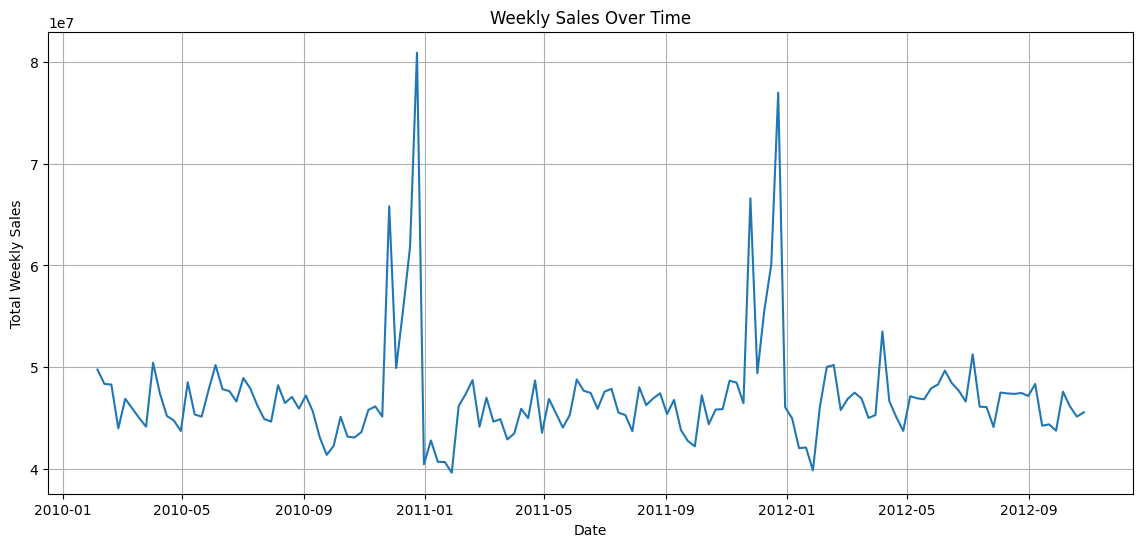

In [14]:
## Weekly Sales Over Time
import matplotlib.pyplot as plt

# Plot weekly sales over time in the training set
plt.figure(figsize=(14, 6))
df_train_merged['date'] = pd.to_datetime(df_train_merged['date'])
sales_over_time = df_train_merged.groupby('date')['weekly_sales'].sum().reset_index()
plt.plot(sales_over_time['date'], sales_over_time['weekly_sales'])
plt.title('Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.grid(True)
plt.show()


Explanation: The line graph depicts the overall weekly sales from 2010 to 2012 for all stores. Significant increases in sales are seen towards the end of the year, possibly linked to the holiday shopping period. These summits coincide with Thanksgiving and Christmas, which are typically busy times for retail sales.

Importance to issues related to business inquiries.

Seasonal Patterns: This chart clearly displays seasonal variations, with notable increases in sales during holidays, especially towards the end of the year. Comprehending this pattern enables pharmacies and stores to predict increased demand in these times and modify inventory to prevent running out of stock.

Inventory Management: Being able to identify these patterns helps in making proactive changes to inventory levels. For instance, getting ready for increased stock levels ahead of holiday peaks can reduce the chances of running out of stock and boost revenue possibilities.


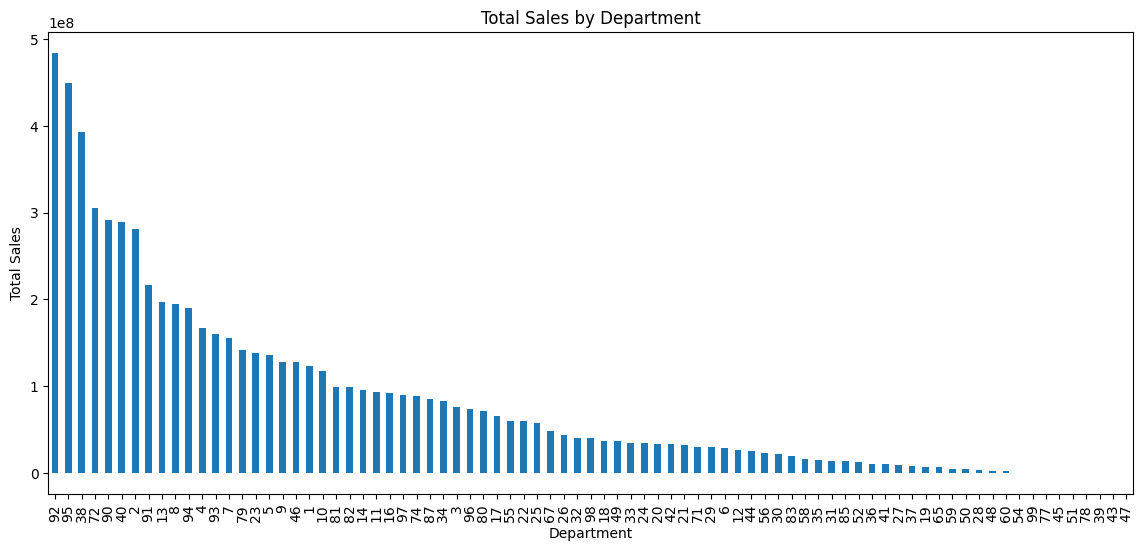

In [15]:
## Sales Distribution Across Departments
# Bar plot of total sales by department
plt.figure(figsize=(14, 6))
dept_sales = df_train_merged.groupby('dept')['weekly_sales'].sum().sort_values(ascending=False)
dept_sales.plot(kind='bar')
plt.title('Total Sales by Department')
plt.xlabel('Department')
plt.ylabel('Total Sales')
plt.show()


Explanation: The bar graph showcases the revenue generated by each department, emphasizing the departments that make the largest contributions to the total revenue. The sales from departments like 92, 95, and 38 make a major contribution to overall sales, while various other departments have lower sales figures.

Importance to inquiries about business:

Forecasting demand: Identifying the departments with the highest sales enables concentrating forecasting efforts on these significant contributors. Pharmacies can ensure they have the right amount of stock in crucial departments by making precise predictions of demand in high-sales areas.

Inventory Prioritization: Departments with lower sales may need restocking less often, enabling more efficient resource allocation. Departments with high sales figures may receive priority for restocking inventory and promotional campaigns.

In [16]:
# Check if 'isholiday_x' and 'isholiday_y' columns are identical
if df_train_merged['isholiday_x'].equals(df_train_merged['isholiday_y']):
    # If they are identical, drop 'isholiday_x' and rename 'isholiday_y' to 'IsHoliday'
    df_train_merged.drop(columns='isholiday_x', inplace=True)
    df_train_merged.rename(columns={'isholiday_y': 'IsHoliday'}, inplace=True)
else:
    # If they are not identical, keep only one (we'll keep 'isholiday_y') and rename it
    df_train_merged.drop(columns='isholiday_x', inplace=True)
    df_train_merged.rename(columns={'isholiday_y': 'IsHoliday'}, inplace=True)

# Repeat the same for the test dataset
if df_test_merged['isholiday_x'].equals(df_test_merged['isholiday_y']):
    df_test_merged.drop(columns='isholiday_x', inplace=True)
    df_test_merged.rename(columns={'isholiday_y': 'IsHoliday'}, inplace=True)
else:
    df_test_merged.drop(columns='isholiday_x', inplace=True)
    df_test_merged.rename(columns={'isholiday_y': 'IsHoliday'}, inplace=True)


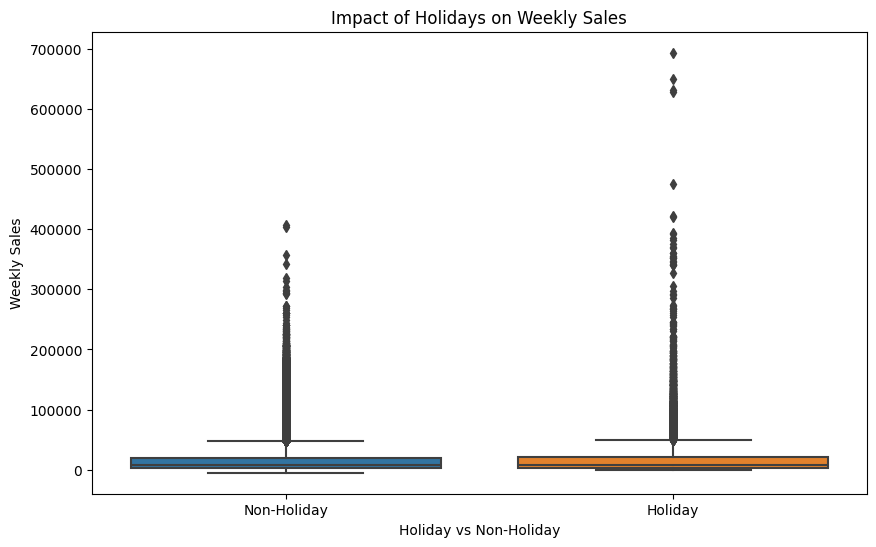

In [17]:
## Impact of Holidays on Weekly Sales
# Box plot of weekly sales during holiday and non-holiday periods
import matplotlib.pyplot as plt
import seaborn as sns

# Map the 'IsHoliday' column to more readable labels for the plot
df_train_merged['is_holiday_label'] = df_train_merged['IsHoliday'].map({True: 'Holiday', False: 'Non-Holiday'})

# Plot the box plot to compare sales on holidays vs non-holidays
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_holiday_label', y='weekly_sales', data=df_train_merged)
plt.title('Impact of Holidays on Weekly Sales')
plt.xlabel('Holiday vs Non-Holiday')
plt.ylabel('Weekly Sales')
plt.show()



Explanation: The box plot compares sales between weeks with holidays and weeks without holidays. Higher median sales occur in weeks with holidays, showing more extreme outliers that represent exceptionally high sales during holiday periods. This indicates that sales receive a significant boost during holidays, although there is considerable fluctuation within each group.

Importance to inquiries related to business:

Holiday Inventory Planning: Demand increases during holidays, demonstrated by higher median values and the occurrence of exceptional outliers. To avoid running out of stock and meet higher demand, pharmacies need to make sure they have enough popular items and essential medications before holidays.

Promotional Planning: This graph provides valuable insights for developing a promotional strategy. For example, strategic marketing can be scheduled during holidays to boost sales, taking advantage of the higher consumer spending during these times.

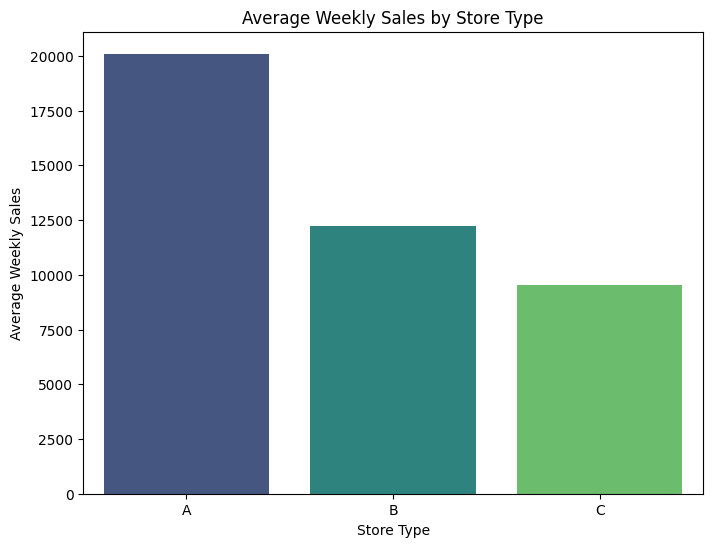

In [18]:
##Bar Plot of Sales by Store Type

import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average weekly sales for each store type
avg_sales_by_type = df_train_merged.groupby('type')['weekly_sales'].mean().reset_index()

# Plot the bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x='type', y='weekly_sales', data=avg_sales_by_type, palette="viridis")
plt.title('Average Weekly Sales by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Average Weekly Sales')
plt.show()



Interpretation: This bar graph displays the mean weekly sales based on the type of store (A, B, and C). Type A stores have much higher weekly sales compared to Types B and C, suggesting that Type A stores serve a larger customer base or offer a wider range of inventory options.

Significance in relation to business inquiries:

Store-specific inventory control: It is recommended for Type A stores to keep a larger amount of inventory due to their higher demand, while Type B and C stores can maintain lower stock levels. Distinguishing between inventory strategies based on store type allows for effective distribution of resources.

Customized Prediction Models: To enhance accuracy, forecasting models need to take into account the different types of stores and their sales variations. Different types of stores have unique demand traits, therefore, specific inventory strategies could be necessary.

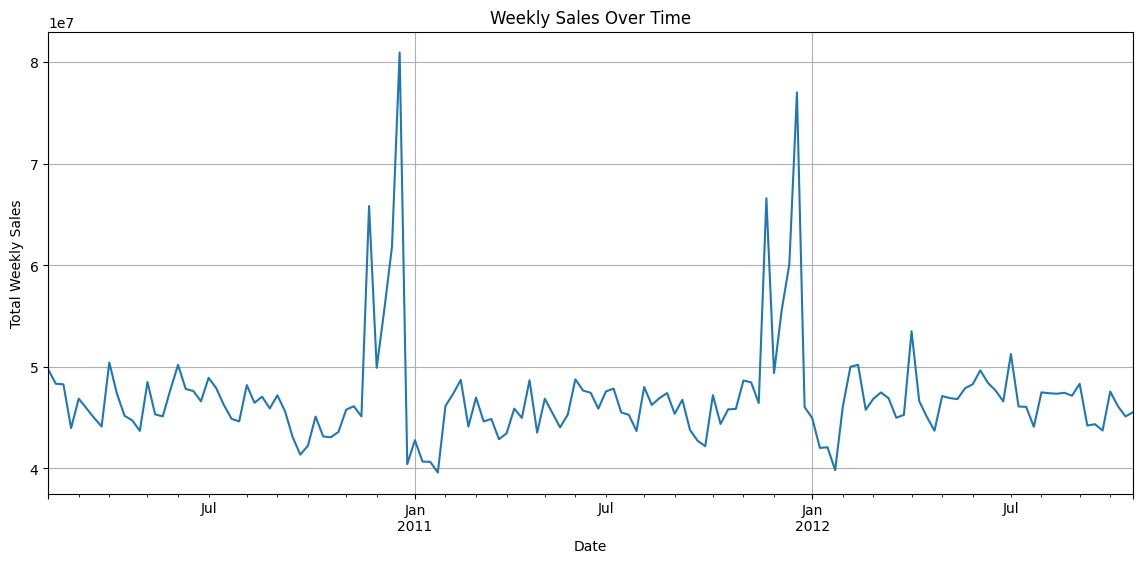

In [19]:
# Sales trends over time
df_train_merged['date'] = pd.to_datetime(df_train_merged['date'])
sales_over_time = df_train_merged.groupby('date')['weekly_sales'].sum()

plt.figure(figsize=(14, 6))
sales_over_time.plot(title='Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.grid()
plt.show()


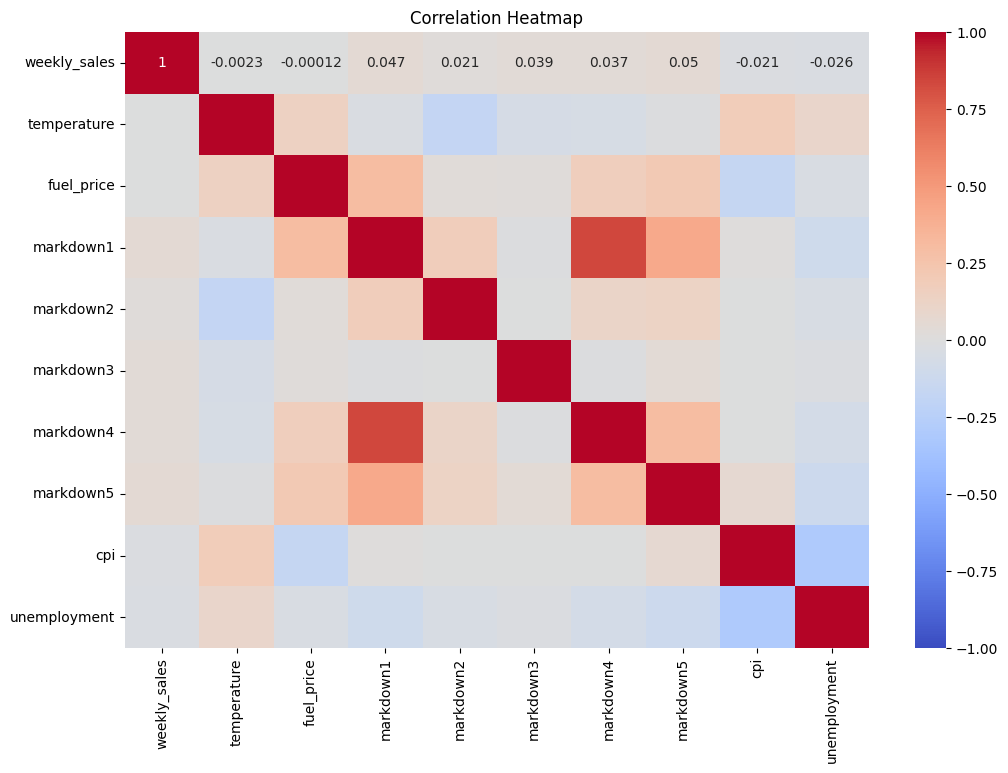

In [20]:
## Correlation 

import seaborn as sns

# Compute the correlation matrix for numerical features
corr_matrix = df_train_merged[['weekly_sales', 'temperature', 'fuel_price', 'markdown1',
                               'markdown2', 'markdown3', 'markdown4', 'markdown5',
                               'cpi', 'unemployment']].corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()


Explanation: The correlation heatmap displays connections between numeric variables within the dataset. A few notable relationships are:

There are strong connections between markdown1, markdown2, markdown4, and weekly_sales, indicating that promotions (markdowns) successfully increase sales.

A minimal or insignificant correlation exists between weekly sales and economic indicators (CPI and Unemployment), suggesting that these variables have little influence on weekly sales in this scenario.

Importance to Business Inquiries:

The impact of promotions on sales: The strong connection between discounts and weekly sales demonstrates that promotions result in increased sales. Pharmacies can use discounts on excess or seasonal items to boost sales and lower stock levels.

Economic Sensitivity: Limited associations between economic indicators such as CPI and unemployment and sales indicate that pharmacy sales may not be heavily influenced by economic conditions, beneficial for stability planning. This understanding can help prioritize internal elements (such as discounts and holidays) over external economic factors when optimizing inventory.

# # Feature selection 

Feature Importances:
size            0.626684
cpi             0.083805
unemployment    0.081631
week            0.071106
temperature     0.045728
fuel_price      0.036770
markdown3       0.012549
markdown5       0.009314
markdown1       0.008182
markdown4       0.008043
markdown2       0.006959
month           0.004940
IsHoliday       0.003247
quarter         0.001043
dtype: float64


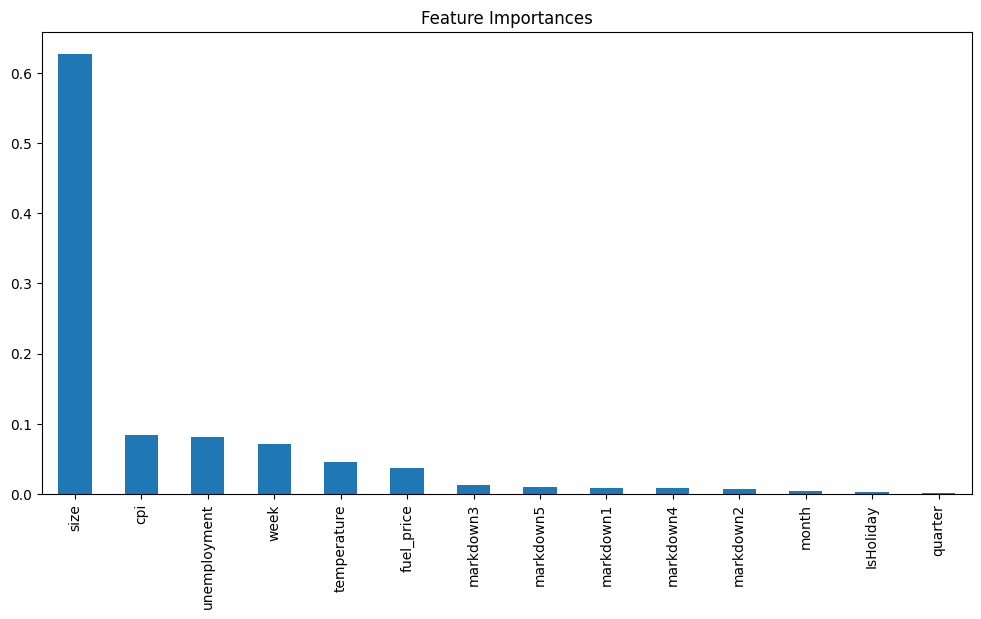

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Define features based on previous analysis and domain knowledge
selected_features = ['temperature', 'fuel_price', 'markdown1', 'markdown2',
                     'markdown3', 'markdown4', 'markdown5', 'cpi', 'unemployment',
                     'week', 'month', 'quarter', 'size', 'IsHoliday']

# Prepare the data
X = df_train_merged[selected_features]
y = df_train_merged['weekly_sales']

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest to see feature importance
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Display feature importances
feature_importances = pd.Series(rf_model.feature_importances_, index=selected_features).sort_values(ascending=False)
print("Feature Importances:")
print(feature_importances)

# Plot feature importances
feature_importances.plot(kind='bar', figsize=(12, 6), title='Feature Importances')
plt.show()


Analysis of Feature Importance:
Size (0.626684): The most significant feature by far, indicating that the size of the store has a substantial impact on weekly sales. This is logical, as larger stores typically serve more customers and have higher sales volumes.

CPI (0.083805) and Unemployment (0.081631): These economic indicators are also influential, suggesting that overall consumer spending trends and economic health can affect sales.

Week (0.071106): Shows that sales exhibit weekly seasonality. This feature captures variations in consumer shopping behavior during different weeks of the year.

Temperature (0.045728) and Fuel Price (0.036770): These external factors are moderately important, likely affecting shopping habits (e.g., extreme weather or fuel prices influencing consumers' willingness to travel).

Markdown3 (0.012549), Markdown5 (0.009314), Markdown1 (0.008182), Markdown4 (0.008043), and Markdown2 (0.006959): Promotions still play a role, albeit smaller, suggesting that while markdowns do increase sales, their relative impact is less significant compared to store size or economic factors.

Month (0.004940) and IsHoliday (0.003247): These features have a minimal influence, but they still capture some of the seasonality and holiday effects that can drive periodic spikes in sales.

Quarter (0.001043): The least important feature, indicating that quarterly data may not be as relevant for forecasting weekly sales in this context.

Feature Selection for Modeling:
Given the feature importance analysis, we can select a subset of features that contribute most to the model's predictive power. A recommended approach would be:

Primary Features: size, cpi, unemployment, week, temperature, fuel_price
Secondary Features (optional): markdown3, markdown5, markdown1, IsHoliday
Why Select These Features?
Size: Strongly impacts sales, likely due to the store's capacity and foot traffic.
Economic Indicators (CPI and Unemployment): Reflect consumer spending power, influencing sales.
Week: Captures seasonality and weekly trends.
Temperature and Fuel Price: External factors that might shift consumer behavior.
Markdowns: While less significant individually, promotions can still impact sales, especially in certain periods.

High Cardinality: The dept variable has 81 unique categories, making it high cardinality and leading to a large number of features after one-hot encoding, increasing complexity and potential overfitting.
Objective Focus: The project's goal is to forecast overall store-level sales, not department-specific trends. Including dept would shift the focus to more granular, less generalizable insights.
Model Simplicity and Interpretability: Excluding dept keeps the model simpler and easier to interpret, allowing for clearer insights on key drivers like size, week, and IsHoliday.
Computational Efficiency: Avoiding the dept variable reduces memory usage and computational load, improving training speed and scalability.

## Linear regression

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Define the selected features
selected_features = ['size', 'cpi', 'unemployment', 'week', 'temperature', 'fuel_price', 
                     'markdown3', 'markdown5', 'markdown1', 'IsHoliday']

# Prepare the data
X = df_train_merged[selected_features]
y = df_train_merged['weekly_sales']

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Predict on the validation set
y_pred = linear_model.predict(X_val)

# Evaluate the model
mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"Linear Regression: MAE = {mae:.2f}, RMSE = {rmse:.2f}")


Linear Regression: MAE = 14507.59, RMSE = 22089.64


## Desicion tree Regressor

In [23]:
from sklearn.tree import DecisionTreeRegressor, export_text

# Initialize and train the Decision Tree Regressor model
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

# Predict on the validation set
y_pred_tree = tree_model.predict(X_val)

# Evaluate the model
mae_tree = mean_absolute_error(y_val, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_val, y_pred_tree))
print(f"Decision Tree: MAE = {mae_tree:.2f}, RMSE = {rmse_tree:.2f}")






Decision Tree: MAE = 14442.26, RMSE = 21960.78


## Random Forest Regressor

In [24]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on the validation set
y_pred_rf = rf_model.predict(X_val)

# Evaluate the model
mae_rf = mean_absolute_error(y_val, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
print(f"Random Forest: MAE = {mae_rf:.2f}, RMSE = {rmse_rf:.2f}")



Random Forest: MAE = 14443.92, RMSE = 21962.38


## XGBoost Regressor

In [25]:
!pip install xgboost


In [26]:
from xgboost import XGBRegressor

# Initialize and train the XGBoost Regressor model
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict on the validation set
y_pred_xgb = xgb_model.predict(X_val)

# Evaluate the model
mae_xgb = mean_absolute_error(y_val, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
print(f"XGBoost: MAE = {mae_xgb:.2f}, RMSE = {rmse_xgb:.2f}")


XGBoost: MAE = 14322.65, RMSE = 21801.51


## LightGBM Regressor

In [27]:
# !pip install lightgbm


# !pip install pandas dask
# !pip install pandas==1.3.3





In [28]:
from lightgbm import LGBMRegressor

# Initialize and train the LightGBM Regressor model
lgb_model = LGBMRegressor(n_estimators=100, random_state=42)
lgb_model.fit(X_train, y_train)

# Predict on the validation set
y_pred_lgb = lgb_model.predict(X_val)

# Evaluate the model
mae_lgb = mean_absolute_error(y_val, y_pred_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_val, y_pred_lgb))
print(f"LightGBM: MAE = {mae_lgb:.2f}, RMSE = {rmse_lgb:.2f}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010320 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1872
[LightGBM] [Info] Number of data points in the train set: 337256, number of used features: 10
[LightGBM] [Info] Start training from score 15979.221909
LightGBM: MAE = 14250.25, RMSE = 21694.53


## Code to Compile Results:

In [29]:
# Create a dictionary with model results
results = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM'],
    'MAE': [mae, mae_tree, mae_rf, mae_xgb, mae_lgb],
    'RMSE': [rmse, rmse_tree, rmse_rf, rmse_xgb, rmse_lgb]
}

# Convert the dictionary to a DataFrame
results_df = pd.DataFrame(results)

# Sort the DataFrame by RMSE for better interpretation
results_df.sort_values(by='RMSE', inplace=True)

# Display the results
print("Model Performance Summary:")
results_df.reset_index(drop=True, inplace=True)
print(results_df)



Model Performance Summary:
               Model           MAE          RMSE
0           LightGBM  14250.248969  21694.533489
1            XGBoost  14322.654503  21801.510137
2      Decision Tree  14442.263370  21960.784056
3      Random Forest  14443.923323  21962.380915
4  Linear Regression  14507.592435  22089.642104


### Purpose of MAE and R
MSE in Model Evaluation:

MAE (Mean Absolute Error):
MAE measures the average magnitude of errors in the predictions, ignoring their direction. It is calculated as the average of the absolute differences between actual and predicted values. MAE provides an intuitive sense of the typical error magnitude in the model's predictions.

Strengths:
Easy to interpret as it is in the same unit as the target variable (e.g., dollars for sales).
Less sensitive to outliers compared to RMSE, making it a robust metric for general error measurement.

RMSE (Root Mean Squared Error):
RMSE measures the square root of the average squared differences between actual and predicted values. By squaring the errors before averaging, RMSE penalizes larger errors more than MAE, making it sensitive to outliers.

Strengths:
Highlights significant deviations between actual and predicted values.
Effective for assessing the performance of models where minimizing larger errors is critical.


### Why Use MAE and MSE?

Practical Applicability:
In our project, the goal is to forecast weekly sales for Walmart stores with high precision to optimize inventory management and promotional strategies. Both MAE and RMSE are expressed in the same units as the target variable (i.e., dollars in weekly sales), making them directly actionable for decision-making. For instance, knowing the average error in terms of weekly sales (e.g., $14,000) provides Walmart with clear expectations of forecasting accuracy, allowing for informed adjustments to inventory levels and stocking strategies.

Balanced Evaluation:
MAE offers a clear understanding of the average error magnitude, enabling us to assess the model’s performance in a straightforward way. This metric ensures that the overall accuracy of sales predictions is measured without being overly influenced by extreme sales fluctuations, such as holiday peaks or special events.
RMSE, on the other hand, emphasizes larger prediction errors, which are critical for Walmart’s business needs. For example, if a significant error occurs during a high-demand holiday season, RMSE highlights such deviations, allowing for focused improvements in those periods.

Model Comparison:
Using MAE and RMSE across all models we tested (e.g., LightGBM, ARIMA, XGBoost), we were able to objectively compare performance. This process helped us identify LightGBM as the best-performing model, as it demonstrated lower MAE and RMSE compared to alternatives, making it the most suitable for accurate forecasting.

By leveraging these metrics, we ensured that our evaluation aligned with Walmart’s need for precise forecasting, balanced treatment of regular and peak sales periods, and the ability to effectively compare model performance to select the most reliable forecasting solution.

### Why Not Use Traditional Statistical Indicators (p-values, Significance Indicators)?

Different Contexts:
P-values and significance indicators are more relevant in statistical hypothesis testing and are often used in traditional linear regression models to determine whether the coefficients of independent variables are statistically significant.
These metrics indicate if there is a significant relationship between a given predictor and the target variable but do not directly inform how well the model as a whole predicts outcomes or performs on new data.

### Machine Learning Perspective:
In machine learning, especially when using models like Decision Trees, Random Forests, XGBoost, and LightGBM, the goal is not to test the significance of individual variables but to build models that generalize well to unseen data.
Models like Random Forest and LightGBM do not produce p-values or traditional significance indicators because they do not rely on linear relationships or assumptions of traditional statistical models. They are non-parametric and can capture complex, non-linear interactions between features.

LightGBM outperforms all other models in terms of both MAE and RMSE, making it the most suitable choice for forecasting sales.
XGBoost is a close alternative and could also be used, especially if LightGBM's training or prediction time is a concern.
The differences between Decision Tree and Random Forest indicate that ensemble methods provide more stability and accuracy over a single decision tree.
Linear Regression shows the highest error, confirming the need for more sophisticated models for better predictive accuracy.

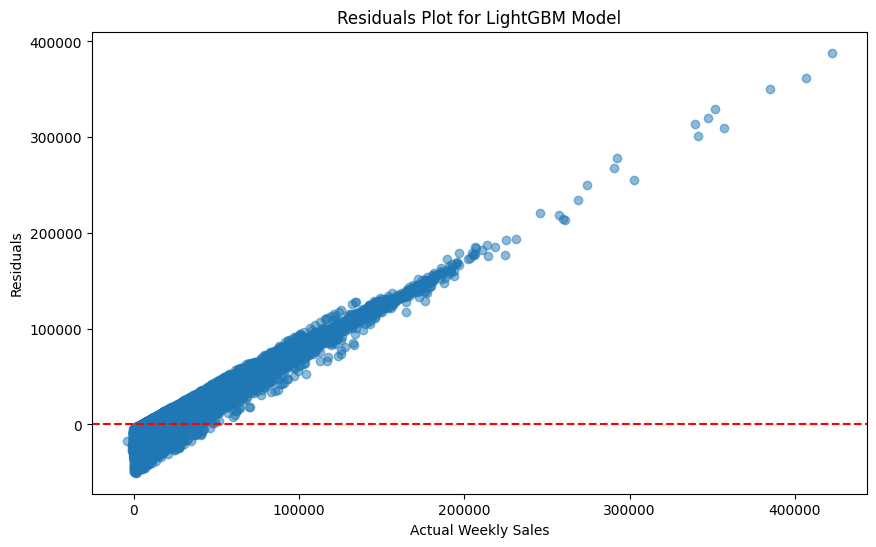

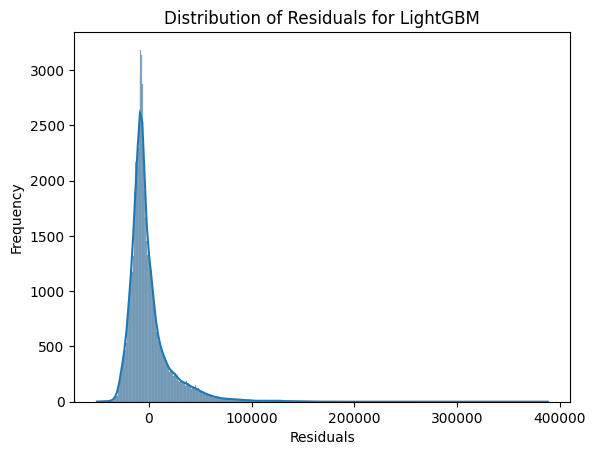

In [30]:
# Calculate residuals for LightGBM predictions
residuals = y_val - y_pred_lgb

# Plot residuals for LightGBM
plt.figure(figsize=(10, 6))
plt.scatter(y_val, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals Plot for LightGBM Model')
plt.xlabel('Actual Weekly Sales')
plt.ylabel('Residuals')
plt.show()

# Error distribution plot
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals for LightGBM')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()


### Residuals Plot for LightGBM
Interpretation: This plot shows the residuals (the difference between actual and predicted sales) against the actual weekly sales values. The majority of residuals are clustered near zero, indicating a generally good fit. However, the spread of residuals increases as actual weekly sales increase, indicating that the model might struggle more with higher sales volumes.
Insight: The model performs well for the majority of the data but may need further refinement or additional features to handle high sales periods accurately.

### Distribution of Residuals for LightGBM

Interpretation: The histogram of residuals shows a peak centered around zero, which is desirable as it indicates most predictions are close to the actual values. However, there is a skew towards positive residuals, indicating that the model may underpredict some of the higher sales figures.
Insight: While the distribution is acceptable, addressing the slight positive skew could involve tuning the model further or incorporating additional relevant features to better capture high sales patterns.

## Walmart's Use of the LightGBM Model

The LightGBM model can be applied by Walmart to make accurate weekly sales forecasts for each store. Let’s take a hypothetical example:

Scenario:
During the holiday season, Walmart needs to ensure adequate stock for high-demand products while avoiding overstocking on less popular items. The LightGBM model predicts weekly sales based on store characteristics, economic indicators, historical trends, and promotional markdowns.

Step-by-Step Usage:
Input Data: Walmart provides the model with inputs such as store size, weekly promotional markdowns, economic indicators (e.g., CPI and Unemployment), and time-based features like the week number and holiday indicators.

Sales Prediction: The LightGBM model predicts weekly sales for each store. For example, it forecasts that Store A will have $1.2 million in sales during Thanksgiving week, with higher demand for electronics and household goods.

Inventory Adjustment: Based on the predictions:

Store A increases stock levels of high-demand items like TVs, gaming consoles, and seasonal decorations.
Reduces stock for low-demand items like back-to-school supplies.
Operational Planning:

Store managers use the predictions to adjust staff schedules, ensuring enough workforce during peak demand.
Marketing teams create targeted promotions for items predicted to sell well, further increasing revenue.

In [31]:
# Step 1: Check and align features
selected_features = ['size', 'cpi', 'unemployment', 'week', 'temperature', 'fuel_price', 
                     'markdown3', 'markdown5', 'markdown1', 'IsHoliday']

# Ensure that only selected features are in X_test
X_test = df_test_merged[selected_features]

# Step 2: Predict baseline sales with existing markdowns
baseline_sales = lgb_model.predict(X_test)

# Step 3: Add baseline predictions to the test dataset
df_test_merged['baseline_sales'] = baseline_sales

# Step 4: Simulate increased markdowns (adjusting markdown1, markdown3, markdown5 by 50%)
df_test_simulated = X_test.copy()
markdown_cols = ['markdown1', 'markdown3', 'markdown5']
for col in markdown_cols:
    df_test_simulated[col] *= 1.5  # Increase selected markdowns by 50%

# Step 5: Predict sales under markdown simulation
simulated_sales = lgb_model.predict(df_test_simulated)
df_test_merged['simulated_sales'] = simulated_sales

# Step 6: Calculate the change in sales due to markdown simulation
df_test_merged['sales_change'] = df_test_merged['simulated_sales'] - df_test_merged['baseline_sales']

# Step 7: Calculate percentage change in sales
df_test_merged['sales_change_percentage'] = (
    (df_test_merged['sales_change'] / df_test_merged['baseline_sales']) * 100
)

# Step 8: Summarize the impact of markdowns
markdown_impact_summary = df_test_merged.groupby('store').agg(
    avg_sales_change=('sales_change', 'mean'),
    total_sales_change=('sales_change', 'sum'),
    avg_sales_change_percentage=('sales_change_percentage', 'mean'),  # Add percentage change summary
    total_sales_change_percentage=('sales_change_percentage', 'sum')  # Add total percentage change summary
).reset_index()

# Step 9: Calculate percentage change for total sales as a new column
markdown_impact_summary['total_sales_change_percentage'] = (
    (markdown_impact_summary['total_sales_change'] / markdown_impact_summary['total_sales_change'].sum()) * 100
)

# Display summary of markdown impact
print("Markdown Impact Summary:")
print(markdown_impact_summary)

# Optional: Save the results for future analysis
markdown_impact_summary.to_csv("markdown_impact_summary.csv", index=False)


Markdown Impact Summary:
    store  avg_sales_change  total_sales_change  avg_sales_change_percentage  \
0       1         98.123612       273078.012366                     0.483568   
1       2        190.401643       532553.394518                     0.774192   
2       3         63.496469       157026.767936                     1.053761   
3       4        118.149732       331173.697792                     0.414681   
4       5         73.850492       180712.152927                     1.313942   
5       6        117.917918       328755.155766                     0.578059   
6       7         44.442183       118616.186535                     0.488209   
7       8         97.890172       264205.574884                     0.792982   
8       9         25.552890        62221.286167                     0.257351   
9      10        -65.924098      -183400.841248                    -0.162492   
10     11         19.954099        54993.498151                     0.106384   
11     12      

###  Markdown Impact Summary
1. High Positive Impact Stores:
#### Store 21:
Avg Sales Change: 203.16
Total Sales Change: 532,082.40
Avg Sales Change Percentage: 1.88%
Total Sales Change Percentage: 8.73%
Interpretation: Store 21 shows the highest positive impact from the markdown simulation. The average sales change of 203.16 and the total sales change of over half a million indicate that markdowns (especially the 50% increase in markdowns) resonate strongly with this store's customer base. The high percentage increase in both average and total sales reflects the success of this strategy in this particular store.
#### Store 20:
Avg Sales Change: 152.62
Total Sales Change: 423,358.74
Avg Sales Change Percentage: 0.58%
Total Sales Change Percentage: 6.95%
Interpretation: Store 20 also benefits significantly from markdowns, with total sales increasing by around 423K, showing a substantial return from the promotional strategy.
#### Store 34:
Avg Sales Change: 136.16
Total Sales Change: 376,751.53
Avg Sales Change Percentage: 1.06%
Total Sales Change Percentage: 6.18%
Interpretation: Similar to Stores 21 and 20, Store 34 sees a large positive impact from the markdown strategy, with a total sales change of about 377K.
2. Moderate Positive Impact Stores:
#### Store 40:
Avg Sales Change: 51.38
Total Sales Change: 140,669.22
Avg Sales Change Percentage: 0.51%
Total Sales Change Percentage: 2.31%
Interpretation: Store 40 shows a moderate increase in sales with markdowns, yielding total sales growth of around 140K. Though not as high as the top-performing stores, it still shows a positive impact.
#### Store 25:
Avg Sales Change: 56.60
Total Sales Change: 151,901.36
Avg Sales Change Percentage: 0.48%
Total Sales Change Percentage: 2.85%
Interpretation: Store 25 also benefits from markdowns, but the increase is moderate compared to others.
3. Low or Negative Impact Stores:
#### Store 27:
Avg Sales Change: -115.36
Total Sales Change: -321,977.11
Avg Sales Change Percentage: -0.36%
Total Sales Change Percentage: -5.28%
Interpretation: Store 27 is the most significantly impacted by the markdown strategy in a negative way, showing both a substantial average and total sales decline. This suggests that markdowns in this store may not be effective, possibly due to oversaturation of discounts or a mismatch between markdowns and customer preferences.
#### Store 10:
Avg Sales Change: -65.92
Total Sales Change: -183,400.84
Avg Sales Change Percentage: -0.16%
Total Sales Change Percentage: -3.01%
Interpretation: Store 10 similarly shows negative impacts from markdowns, with total sales decreasing by over 183K. A potential reason could be local factors like high competition, product mix issues, or regional demand.
#### Store 22:
Avg Sales Change: -50.67
Total Sales Change: -132,649.46
Avg Sales Change Percentage: -0.20%
Total Sales Change Percentage: -2.18%
Interpretation: Store 22 shows another decline, though less severe than Store 27. The results indicate that markdowns aren't translating to significant sales gains here.
4. Minor Positive Impact Stores:
#### Store 6:
Avg Sales Change: 117.92
Total Sales Change: 328,755.16
Avg Sales Change Percentage: 0.58%
Total Sales Change Percentage: 5.40%
Interpretation: While Store 6 shows a modest increase in sales due to markdowns, it's not as pronounced as the top-performing stores.
#### Store 18:
Avg Sales Change: -49.85
Total Sales Change: -134,483.47
Avg Sales Change Percentage: -0.18%
Total Sales Change Percentage: -2.21%
Interpretation: Store 18 is another underperformer with negative results from markdowns. Like other stores with negative results, this indicates a need for reviewing the markdown approach here.
### Summary Insights:
#### High-Impact Stores:
Stores 21, 20, and 34 exhibit strong sales growth due to markdowns, making them ideal candidates for markdown campaigns, especially during peak sales periods.
#### Low-Impact or Negative Impact Stores:
Stores 27, 10, and 22 show negative sales changes, indicating that markdown strategies might not be effective for these locations. These stores may benefit from reassessing markdown levels, considering local factors, or testing alternative promotional strategies (e.g., bundle deals, product mix adjustments).
#### Moderate Performers:
Stores like 40, 25, and others see moderate improvements in sales. These stores should continue receiving markdown attention but might not require the same intensity of markdowns as high-performing stores.
### Actionable Recommendations:
#### Tailor Markdown Strategies: 
Consider applying more aggressive markdowns in high-performing stores and re-evaluating markdown effectiveness in underperforming stores.
#### Monitor Regional Variability:
Conduct further analysis on regional demand, competition, and local customer preferences for stores with negative or low sales impact.
#### Leverage Data for Dynamic Adjustments:
Use real-time sales data to adjust markdown strategies dynamically across different stores.

In [32]:
df_train_merged.head()

,store,dept,date,weekly_sales,temperature,fuel_price,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment,IsHoliday,type,size,week,month,quarter,year,is_holiday_label
0,1,1,2010-02-05,24924.50,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,False,A,151315,5,2,1,2010,Non-Holiday
1,1,1,2010-02-12,46039.49,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,True,A,151315,6,2,1,2010,Holiday
2,1,1,2010-02-19,41595.55,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,False,A,151315,7,2,1,2010,Non-Holiday
3,1,1,2010-02-26,19403.54,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,False,A,151315,8,2,1,2010,Non-Holiday
4,1,1,2010-03-05,21827.90,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,False,A,151315,9,3,1,2010,Non-Holiday



Predicted Sales for Scenario: High Unemployment, Low CPI, High Fuel Price, Low Temperature

Predicted Sales (Without Markdown):
        store  predicted_sales
0           1     21706.734983
1           1     21763.537832
2           1     21429.148068
3           1     21792.940546
4           1     19319.481215
...       ...              ...
115059     45     18860.815579
115060     45     18850.306797
115061     45     19516.791900
115062     45     19111.235278
115063     45     18743.330172

[115064 rows x 2 columns]

Predicted Sales (With 50% Markdown):
        store  predicted_sales
0           1     21567.347650
1           1     21433.155490
2           1     21696.878748
3           1     22097.554481
4           1     19098.842204
...       ...              ...
115059     45     18601.601437
115060     45     19093.590090
115061     45     19825.252942
115062     45     19212.165214
115063     45     18743.330172

[115064 rows x 2 columns]

Predicted Sales for Scenario: Low 

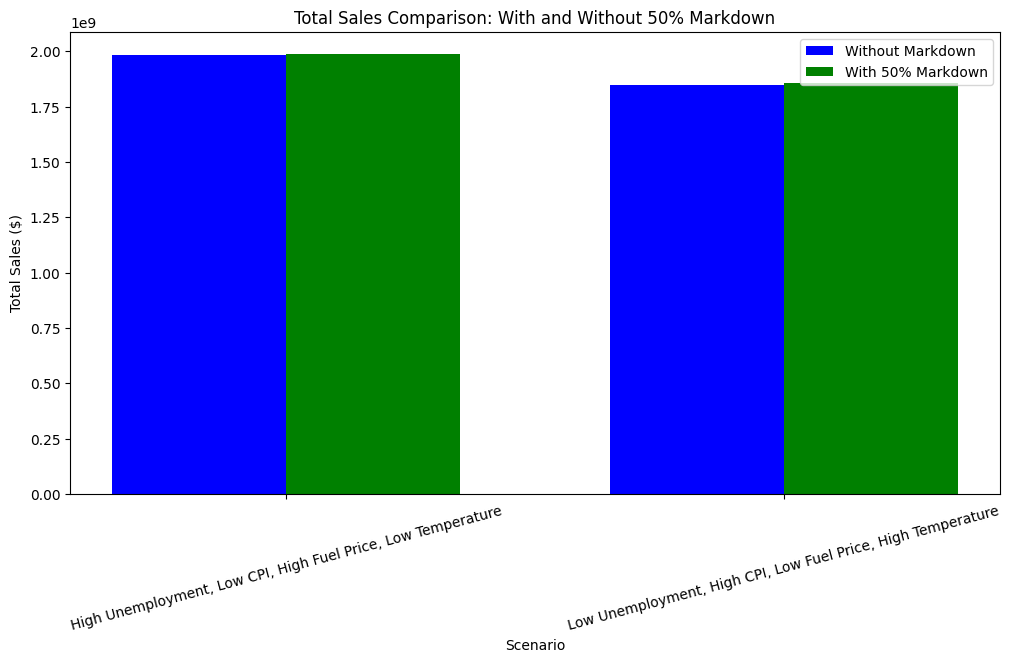

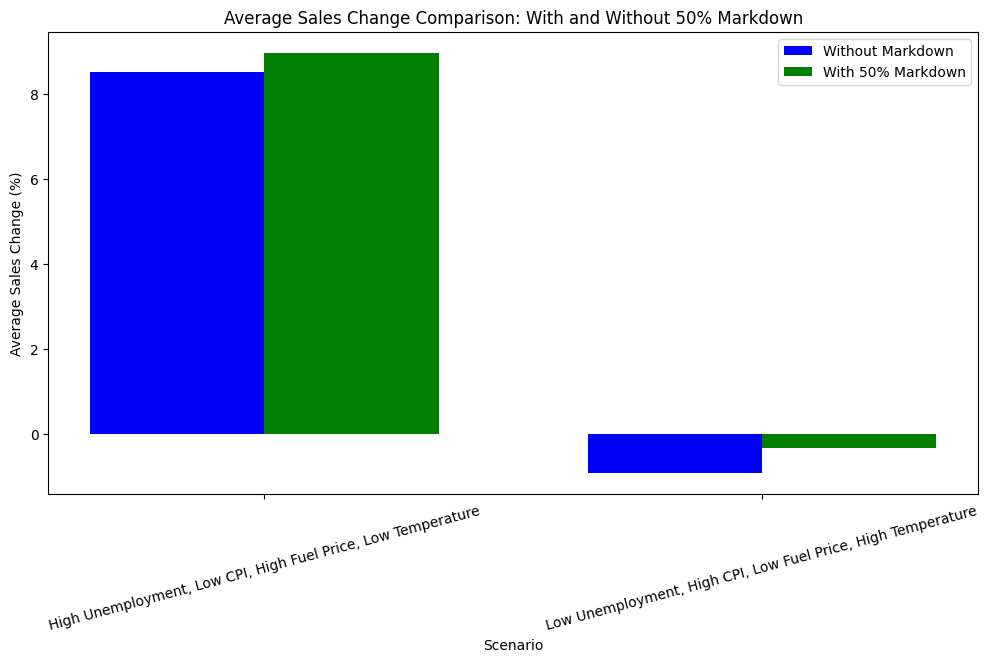

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Assume df_test_merged and lgb_model are preloaded and preprocessed
# df_test_merged should have the required features: ['size', 'cpi', 'unemployment', 'week', 'temperature', 'fuel_price', 'IsHoliday', 'markdown1', 'markdown3', 'markdown5']
# lgb_model should be a trained LightGBM Regressor

# Define markdown scenarios for first and second scenarios (both with and without 50% markdown)
markdown_conditions = [
    {"scenario": "High Unemployment, Low CPI, High Fuel Price, Low Temperature", 
     "unemployment": 3.6, "cpi": 290, "fuel_price": 4.499, "temperature": 32,
     "markdowns": {"markdown1": 0.0, "markdown3": 0.0, "markdown5": 0.0},  # No markdowns
     "markdowns_with_50": {"markdown1": 0.5, "markdown3": 0.5, "markdown5": 0.5}},  # 50% markdowns
    
    {"scenario": "Low Unemployment, High CPI, Low Fuel Price, High Temperature", 
     "unemployment": 2.5, "cpi": 320, "fuel_price": 3.0, "temperature": 95,
     "markdowns": {"markdown1": 0.0, "markdown3": 0.0, "markdown5": 0.0},  # No markdowns
     "markdowns_with_50": {"markdown1": 0.5, "markdown3": 0.5, "markdown5": 0.5}}  # 50% markdowns
]

# Analyze impact of markdown scenarios
results = []

for condition in markdown_conditions:
    # Create a copy of test data for both scenarios (with and without 50% markdown)
    test_data_no_markdown = df_test_merged.copy()
    test_data_with_50 = df_test_merged.copy()
    
    # Set economic conditions for both scenarios
    test_data_no_markdown['unemployment'] = condition['unemployment']
    test_data_no_markdown['cpi'] = condition['cpi']
    test_data_no_markdown['fuel_price'] = condition['fuel_price']
    test_data_no_markdown['temperature'] = condition['temperature']
    
    test_data_with_50['unemployment'] = condition['unemployment']
    test_data_with_50['cpi'] = condition['cpi']
    test_data_with_50['fuel_price'] = condition['fuel_price']
    test_data_with_50['temperature'] = condition['temperature']
    
    # Apply markdowns (no markdowns vs. 50% markdowns)
    for col, change in condition['markdowns'].items():
        test_data_no_markdown[col] *= (1 + change)  # No markdowns
    
    for col, change in condition['markdowns_with_50'].items():
        test_data_with_50[col] *= (1 + change)  # Apply 50% markdowns
    
    # Predict sales under both scenarios
    test_data_no_markdown['predicted_sales'] = lgb_model.predict(test_data_no_markdown[selected_features])
    test_data_with_50['predicted_sales'] = lgb_model.predict(test_data_with_50[selected_features])
    
    # Predict baseline sales for comparison
    baseline_data = df_test_merged.copy()
    baseline_data['predicted_sales'] = lgb_model.predict(baseline_data[selected_features])
    
    # Calculate percentage sales change for both scenarios
    test_data_no_markdown['sales_change'] = (
        (test_data_no_markdown['predicted_sales'] - baseline_data['predicted_sales']) / 
        baseline_data['predicted_sales']
    ) * 100

    test_data_with_50['sales_change'] = (
        (test_data_with_50['predicted_sales'] - baseline_data['predicted_sales']) / 
        baseline_data['predicted_sales']
    ) * 100

    # Aggregate results for both scenarios
    total_sales_no_markdown = test_data_no_markdown['predicted_sales'].sum()
    avg_sales_change_no_markdown = test_data_no_markdown['sales_change'].mean()

    total_sales_with_50 = test_data_with_50['predicted_sales'].sum()
    avg_sales_change_with_50 = test_data_with_50['sales_change'].mean()
    
    results.append({
        "Scenario": condition["scenario"],
        "Total Sales Without Markdown": total_sales_no_markdown,
        "Average Sales Change Without Markdown (%)": avg_sales_change_no_markdown,
        "Total Sales With 50% Markdown": total_sales_with_50,
        "Average Sales Change With 50% Markdown (%)": avg_sales_change_with_50
    })
    
    # Display Predicted Sales for both scenarios (with and without markdowns)
    print(f"\nPredicted Sales for Scenario: {condition['scenario']}")
    
    # Store-level predicted sales for both cases
    store_sales_no_markdown = test_data_no_markdown[['store', 'predicted_sales']]
    store_sales_with_50 = test_data_with_50[['store', 'predicted_sales']]
    
    # Display predicted sales for each store (without markdown)
    print("\nPredicted Sales (Without Markdown):")
    print(store_sales_no_markdown)
    
    # Display predicted sales for each store (with 50% markdown)
    print("\nPredicted Sales (With 50% Markdown):")
    print(store_sales_with_50)

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print("\nScenario Results Summary:")
print(results_df)

# Visualize overall results: Total Sales for each scenario with and without 50% markdown
plt.figure(figsize=(12, 6))
bar_width = 0.35
index = range(len(results_df))

# Total sales comparison
plt.bar(index, results_df["Total Sales Without Markdown"], bar_width, label='Without Markdown', color='blue')
plt.bar([i + bar_width for i in index], results_df["Total Sales With 50% Markdown"], bar_width, label='With 50% Markdown', color='green')

plt.xlabel("Scenario")
plt.ylabel("Total Sales ($)")
plt.title("Total Sales Comparison: With and Without 50% Markdown")
plt.xticks([i + bar_width / 2 for i in index], results_df["Scenario"], rotation=15)
plt.legend()
plt.show()

# Visualize overall results: Average Sales Change for each scenario with and without 50% markdown
plt.figure(figsize=(12, 6))
plt.bar(index, results_df["Average Sales Change Without Markdown (%)"], bar_width, label='Without Markdown', color='blue')
plt.bar([i + bar_width for i in index], results_df["Average Sales Change With 50% Markdown (%)"], bar_width, label='With 50% Markdown', color='green')

plt.xlabel("Scenario")
plt.ylabel("Average Sales Change (%)")
plt.title("Average Sales Change Comparison: With and Without 50% Markdown")
plt.xticks([i + bar_width / 2 for i in index], results_df["Scenario"], rotation=15)
plt.legend()
plt.show()


### Scenario Results Summary:

#### High Unemployment, Low CPI, High Fuel Price, Low Temperature:
    Total Sales Without Markdown: 1.98 billion
    Average Sales Change Without Markdown: 8.51%
    Total Sales With 50% Markdown: 1.99 billion
    Average Sales Change With 50% Markdown: 8.97%
#### Low Unemployment, High CPI, Low Fuel Price, High Temperature:
    Total Sales Without Markdown: 1.85 billion
    Average Sales Change Without Markdown: -0.92%
    Total Sales With 50% Markdown: 1.86 billion
    Average Sales Change With 50% Markdown: -0.34%

In [34]:
# Function to apply scenario conditions and handle variables
def apply_scenario(test_data, scenario):
    test_data = test_data.copy()
    markdown_cols = ['markdown1', 'markdown3', 'markdown5']
    
    # Default values based on the dataset's median values or mode for categorical data
    default_values = {
        "temperature": test_data['temperature'].median(),  # Median temperature from the dataset
        "holiday": test_data['IsHoliday'].mode()[0],       # Most common holiday status
        "cpi": test_data['cpi'].median(),                  # Median CPI from the dataset
        "unemployment": test_data['unemployment'].median(), # Median unemployment rate
        "fuel_price": test_data['fuel_price'].median()      # Median fuel price from the dataset
    }
    
    # Adjust markdowns based on the markdown factor provided in the scenario
    for col in markdown_cols:
        test_data[col] *= scenario.get("markdown_factor", 1.0)
    
    # Handle temperature adjustments (replace with default if not provided)
    if scenario.get("temperature") is not None:
        test_data['temperature'] = scenario['temperature']
    else:
        test_data['temperature'] = default_values['temperature']
    
    # Handle other variables, applying defaults where necessary
    if scenario.get("holiday") is not None:
        test_data['IsHoliday'] = scenario['holiday']
    else:
        test_data['IsHoliday'] = default_values['holiday']
    
    if scenario.get("cpi") is not None:
        test_data['cpi'] = scenario['cpi']
    else:
        test_data['cpi'] = default_values['cpi']
    
    if scenario.get("unemployment") is not None:
        test_data['unemployment'] = scenario['unemployment']
    else:
        test_data['unemployment'] = default_values['unemployment']
    
    if scenario.get("fuel_price") is not None:
        test_data['fuel_price'] = scenario['fuel_price']
    else:
        test_data['fuel_price'] = default_values['fuel_price']
    
    # Print the values that are applied (including defaults)
    print(f"\nScenario: {scenario['scenario']}")
    print(f"Markdown Factor: {scenario.get('markdown_factor', 'Not Provided')}")
    print(f"Temperature: {test_data['temperature'].iloc[0]}")
    print(f"Holiday: {test_data['IsHoliday'].iloc[0]}")
    print(f"CPI: {test_data['cpi'].iloc[0]}")
    print(f"Unemployment: {test_data['unemployment'].iloc[0]}")
    print(f"Fuel Price: {test_data['fuel_price'].iloc[0]}")

    return test_data


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_test_merged, lgb_model, and selected_features are preloaded

# Define scenarios
scenarios = [
    {"scenario": "Markdown Impact Analysis (50% Increase)", "markdown_factor": 1.5, "temperature": None, "holiday": None, "fuel_price": None, "unemployment": 3.9},
    {"scenario": "Markdown Impact Analysis (50% Decrease)", "markdown_factor": 0.5, "temperature": None, "holiday": None, "fuel_price": None, "unemployment": 3.9},
    {"scenario": "Extreme Cold Weather", "markdown_factor": 1.0, "temperature": 48.2, "holiday": None},
    {"scenario": "Extreme Hot Weather", "markdown_factor": 1.0, "temperature": 100, "holiday": None},
    {"scenario": "High CPI and Low Unemployment", "markdown_factor": 1.0, "temperature": None, "holiday": None, "cpi": 320, "unemployment": 2.5},
    {"scenario": "Low CPI and High Unemployment", "markdown_factor": 1.0, "temperature": None, "holiday": None, "cpi": 290, "unemployment": 6.0},
]

# Function to apply scenario conditions and handle variables
def apply_scenario(test_data, scenario):
    test_data = test_data.copy()
    markdown_cols = ['markdown1', 'markdown3', 'markdown5']
    
    # Adjust markdowns
    for col in markdown_cols:
        test_data[col] *= scenario.get("markdown_factor", 1.0)
    
    # Handle temperature adjustments and negative values
    if scenario.get("temperature") is not None:
        test_data['temperature'] = scenario['temperature']
    test_data['temperature'] = test_data['temperature'].apply(lambda x: max(x, 0))  # Replace negative temperatures with 0
    
    # Adjust other scenario-specific conditions
    if scenario.get("holiday") is not None:
        test_data['IsHoliday'] = scenario['holiday']
    if scenario.get("cpi") is not None:
        test_data['cpi'] = scenario['cpi']
    if scenario.get("unemployment") is not None:
        test_data['unemployment'] = scenario['unemployment']
    if scenario.get("fuel_price") is not None:
        test_data['fuel_price'] = scenario['fuel_price']
    
    return test_data

# Baseline prediction
baseline_data = df_test_merged.copy()
baseline_data['predicted_sales'] = lgb_model.predict(baseline_data[selected_features])
baseline_store_sales = baseline_data.groupby('store')['predicted_sales'].sum().reset_index()
baseline_store_sales.rename(columns={'predicted_sales': 'Baseline Sales'}, inplace=True)

# Analyze each scenario
store_results = baseline_store_sales.copy()
for scenario in scenarios:
    test_data = apply_scenario(df_test_merged, scenario)
    test_data['predicted_sales'] = lgb_model.predict(test_data[selected_features])
    scenario_sales = test_data.groupby('store')['predicted_sales'].sum().reset_index()
    scenario_sales.rename(columns={'predicted_sales': scenario['scenario']}, inplace=True)
    store_results = pd.merge(store_results, scenario_sales, on='store', how='left')

# Calculate total sales percentage change for each scenario
total_sales_changes = {}
for scenario in scenarios:
    scenario_name = scenario['scenario']
    baseline_total = store_results['Baseline Sales'].sum()
    scenario_total = store_results[scenario_name].sum()
    percentage_change = ((scenario_total - baseline_total) / baseline_total) * 100
    total_sales_changes[scenario_name] = percentage_change

# Display total sales percentage change
print("\nChange in Total Sales Percentage for Each Scenario:")
for scenario, change in total_sales_changes.items():
    print(f"{scenario}: {change:.2f}%")

# Save the results for all scenarios
store_results.to_csv("store_level_scenario_results.csv", index=False)
print("\nStore-level scenario results saved to 'store_level_scenario_results.csv'")



Change in Total Sales Percentage for Each Scenario:
Markdown Impact Analysis (50% Increase): 14.39%
Markdown Impact Analysis (50% Decrease): 12.48%
Extreme Cold Weather: -0.85%
Extreme Hot Weather: -5.31%
High CPI and Low Unemployment: 2.87%
Low CPI and High Unemployment: -5.63%

Store-level scenario results saved to 'store_level_scenario_results.csv'


In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_test_merged, lgb_model, and selected_features are preloaded

# Define scenarios with only the first two retained and CPI applied
scenarios = [
    {"scenario": "Markdown Impact Analysis (50% Increase) -> 1", "markdown_factor": 1.5, "temperature": None, "holiday": True, "fuel_price": 3.91, "unemployment": None, "cpi": None},
    {"scenario": "Markdown Impact Analysis (50% Decrease) -> 2", "markdown_factor": 0.5, "temperature": None, "holiday": True, "fuel_price": 3.91, "unemployment": None, "cpi": 182.3187801},
]

# Function to apply scenario conditions and handle variables
def apply_scenario(test_data, scenario):
    test_data = test_data.copy()
    markdown_cols = ['markdown1', 'markdown3', 'markdown5']
    
    # Adjust markdowns
    markdown_factor = scenario.get("markdown_factor", 1.0)
    for col in markdown_cols:
        test_data[col] *= markdown_factor
    
    # Handle temperature adjustments and negative values
    if scenario.get("temperature") is not None:
        test_data['temperature'] = scenario['temperature']
    else:
        # Replace with median if 'temperature' is None
        median_temp = test_data['temperature'].median()
        print(f"Temperature is None, replacing with median: {median_temp}")
        test_data['temperature'] = median_temp

    test_data['temperature'] = test_data['temperature'].apply(lambda x: max(x, 0))  # Replace negative temperatures with 0
    
    # Adjust other scenario-specific conditions
    if scenario.get("holiday") is not None:
        test_data['IsHoliday'] = scenario['holiday']
    else:
        # Replace with mode if 'holiday' is None (mode is the most frequent value)
        mode_holiday = test_data['IsHoliday'].mode()[0]
        print(f"Holiday is None, replacing with mode: {mode_holiday}")
        test_data['IsHoliday'] = mode_holiday

    # Handle CPI: Replace with scenario value if provided, else use the median value
    if scenario.get("cpi") is not None:
        test_data['cpi'] = scenario['cpi']
    else:
        # Replace with median if 'cpi' is None
        median_cpi = test_data['cpi'].median()
        print(f"CPI is None, replacing with median: {median_cpi}")
        test_data['cpi'] = median_cpi
    
    # Handle unemployment: Replace with scenario value if provided, else use the median value
    if scenario.get("unemployment") is not None:
        test_data['unemployment'] = scenario['unemployment']
    else:
        # Replace with median if 'unemployment' is None
        median_unemployment = test_data['unemployment'].median()
        print(f"Unemployment is None, replacing with median: {median_unemployment}")
        test_data['unemployment'] = median_unemployment
    
    # Handle fuel price: Replace with scenario value if provided, else use the median value
    if scenario.get("fuel_price") is not None:
        test_data['fuel_price'] = scenario['fuel_price']
    else:
        # Replace with median if 'fuel_price' is None
        median_fuel_price = test_data['fuel_price'].median()
        print(f"Fuel Price is None, replacing with median: {median_fuel_price}")
        test_data['fuel_price'] = median_fuel_price
    
    # Print the default values used for each variable
    print("\nDefault Values Used in the Scenario:")
    print(f"Temperature: {test_data['temperature'].median()}")
    print(f"Holiday: {test_data['IsHoliday'].mode()[0]}")
    print(f"CPI: {test_data['cpi'].median()}")
    print(f"Unemployment: {test_data['unemployment'].median()}")
    print(f"Fuel Price: {test_data['fuel_price'].median()}")
    
    return test_data

# Baseline prediction
baseline_data = df_test_merged.copy()
baseline_data['predicted_sales'] = lgb_model.predict(baseline_data[selected_features])
baseline_store_sales = baseline_data.groupby('store')['predicted_sales'].sum().reset_index()
baseline_store_sales.rename(columns={'predicted_sales': 'Baseline Sales'}, inplace=True)

# Analyze each scenario
store_results = baseline_store_sales.copy()

# Apply both scenarios, replacing `None` with default values
for scenario in scenarios:
    print(f"\nApplying scenario: {scenario['scenario']}")
    test_data = apply_scenario(df_test_merged, scenario)
    
    # Predict sales based on the scenario
    test_data['predicted_sales'] = lgb_model.predict(test_data[selected_features])
    
    # Aggregating sales by store for this scenario
    scenario_sales = test_data.groupby('store')['predicted_sales'].sum().reset_index()
    
    # Ensure the scenario name is used as the column name
    scenario_sales.rename(columns={'predicted_sales': scenario['scenario']}, inplace=True)
    
    # Merge the scenario sales into the store_results DataFrame
    store_results = pd.merge(store_results, scenario_sales, on='store', how='left')

# Calculate total sales percentage change for each scenario
total_sales_changes = {}
for scenario in scenarios:
    scenario_name = scenario['scenario']
    baseline_total = store_results['Baseline Sales'].sum()
    scenario_total = store_results[scenario_name].sum()
    percentage_change = ((scenario_total - baseline_total) / baseline_total) * 100
    total_sales_changes[scenario_name] = percentage_change

# Display total sales percentage change
print("\nChange in Total Sales Percentage for Each Scenario:")
for scenario, change in total_sales_changes.items():
    print(f"{scenario}: {change:.2f}%")

# Save the results for all scenarios
store_results.to_csv("store_level_scenario_results.csv", index=False)
print("\nStore-level scenario results saved to 'store_level_scenario_results.csv'")



Applying scenario: Markdown Impact Analysis (50% Increase) -> 1
Temperature is None, replacing with median: 54.47
CPI is None, replacing with median: 182.3187801
Unemployment is None, replacing with median: 7.866

Default Values Used in the Scenario:
Temperature: 54.47
Holiday: True
CPI: 182.3187801
Unemployment: 7.866
Fuel Price: 3.91

Applying scenario: Markdown Impact Analysis (50% Decrease) -> 2
Temperature is None, replacing with median: 54.47
Unemployment is None, replacing with median: 7.866

Default Values Used in the Scenario:
Temperature: 54.47
Holiday: True
CPI: 182.3187801
Unemployment: 7.866
Fuel Price: 3.91

Change in Total Sales Percentage for Each Scenario:
Markdown Impact Analysis (50% Increase) -> 1: 1.92%
Markdown Impact Analysis (50% Decrease) -> 2: 2.26%

Store-level scenario results saved to 'store_level_scenario_results.csv'


In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_test_merged, lgb_model, and selected_features are preloaded

# Define scenarios with the first two retained and CPI applied
scenarios = [
    {"scenario": "Markdown Impact Analysis (50% Increase) -> 1", "markdown_factor": 1.5, "temperature": None, "holiday": True, "fuel_price": 3.91, "unemployment": None, "cpi": None},
    {"scenario": "Markdown Impact Analysis (50% Decrease) -> 2", "markdown_factor": 0.5, "temperature": None, "holiday": True, "fuel_price": 3.91, "unemployment": None, "cpi": 182.3187801},
    {"scenario": "High Temperature Increased Markdown (96°F), No Holiday", "markdown_factor": 1.5, "temperature": 96, "holiday": False, "fuel_price": None, "unemployment": None, "cpi": None},
    {"scenario": "High Temperature Decreased Markdown (96°F), No Holiday", "markdown_factor": 0.5, "temperature": 96, "holiday": False, "fuel_price": None, "unemployment": None, "cpi": None},
    {"scenario": "High Temperature Increased Markdown (96°F), Holiday", "markdown_factor": 1.5, "temperature": 96, "holiday": True, "fuel_price": None, "unemployment": None, "cpi": None},
    {"scenario": "High Temperature Decreased Markdown (96°F), Holiday", "markdown_factor": 0.5, "temperature": 96, "holiday": True, "fuel_price": None, "unemployment": None, "cpi": None},
    {"scenario": "Low Temperature Increased Markdown (16°F), No Holiday", "markdown_factor": 1.5, "temperature": 16, "holiday": False, "fuel_price": None, "unemployment": None, "cpi": None},
    {"scenario": "Low Temperature Decreased Markdown (16°F), No Holiday", "markdown_factor": 0.5, "temperature": 16, "holiday": False, "fuel_price": None, "unemployment": None, "cpi": None},
    {"scenario": "Low Temperature Increased Markdown (16°F), Holiday", "markdown_factor": 1.5, "temperature": 16, "holiday": True, "fuel_price": None, "unemployment": None, "cpi": None},
    {"scenario": "Low Temperature Decreased Markdown (16°F), Holiday", "markdown_factor": 0.5, "temperature": 16, "holiday": True, "fuel_price": None, "unemployment": None, "cpi": None},
    {"scenario": "Low Unemployment Increased Markdown (3.1%), No Holiday", "markdown_factor": 1.5, "temperature": None, "holiday": False, "fuel_price": None, "unemployment": 3.1, "cpi": None},
    {"scenario": "Low Unemployment Decreased Markdown (3.1%), No Holiday", "markdown_factor": 0.5, "temperature": None, "holiday": False, "fuel_price": None, "unemployment": 3.1, "cpi": None},
    {"scenario": "Low Unemployment Increased Markdown (3.1%), Holiday", "markdown_factor": 1.5, "temperature": None, "holiday": True, "fuel_price": None, "unemployment": 3.1, "cpi": None},
    {"scenario": "Low Unemployment Decreased Markdown (3.1%), Holiday", "markdown_factor": 0.5, "temperature": None, "holiday": True, "fuel_price": None, "unemployment": 3.1, "cpi": None},
    {"scenario": "High Unemployment Increased Markdown (3.4%), No Holiday", "markdown_factor": 1.5, "temperature": None, "holiday": False, "fuel_price": None, "unemployment": 3.4, "cpi": None},
    {"scenario": "High Unemployment Decreased Markdown (3.4%), No Holiday", "markdown_factor": 0.5, "temperature": None, "holiday": False, "fuel_price": None, "unemployment": 3.4, "cpi": None},
    {"scenario": "High Unemployment Increased Markdown (3.4%), Holiday", "markdown_factor": 1.5, "temperature": None, "holiday": True, "fuel_price": None, "unemployment": 3.4, "cpi": None},
    {"scenario": "High Unemployment Decreased Markdown (3.4%), Holiday", "markdown_factor": 0.5, "temperature": None, "holiday": True, "fuel_price": None, "unemployment": 3.4, "cpi": None},
    {"scenario": "Low Fuel Increased Markdown (2.66), No Holiday", "markdown_factor": 1.5, "temperature": None, "holiday": False, "fuel_price": 2.66, "unemployment": None, "cpi": None},
    {"scenario": "Low Fuel Decreased Markdown (2.66), No Holiday", "markdown_factor": 0.5, "temperature": None, "holiday": False, "fuel_price": 2.66, "unemployment": None, "cpi": None},
    {"scenario": "Low Fuel Increased Markdown (2.66), Holiday", "markdown_factor": 1.5, "temperature": None, "holiday": True, "fuel_price": 2.66, "unemployment": None, "cpi": None},
    {"scenario": "Low Fuel Decreased Markdown (2.66), Holiday", "markdown_factor": 0.5, "temperature": None, "holiday": True, "fuel_price": 2.66, "unemployment": None, "cpi": None},
    {"scenario": "High Fuel Increased Markdown (3.91), No Holiday", "markdown_factor": 1.5, "temperature": None, "holiday": False, "fuel_price": 3.91, "unemployment": None, "cpi": None},
    {"scenario": "High Fuel Decreased Markdown (3.91), No Holiday", "markdown_factor": 0.5, "temperature": None, "holiday": False, "fuel_price": 3.91, "unemployment": None, "cpi": None},
    {"scenario": "High Fuel Increased Markdown (3.91), Holiday", "markdown_factor": 1.5, "temperature": None, "holiday": True, "fuel_price": 3.91, "unemployment": None, "cpi": None},
    {"scenario": "High Fuel Decreased Markdown (3.91), Holiday", "markdown_factor": 0.5, "temperature": None, "holiday": True, "fuel_price": 3.91, "unemployment": None, "cpi": None},
]

# Function to apply scenario conditions and handle variables
def apply_scenario(test_data, scenario):
    test_data = test_data.copy()
    markdown_cols = ['markdown1', 'markdown3', 'markdown5']
    
    # Adjust markdowns based on markdown_factor
    markdown_factor = scenario.get("markdown_factor", 1.0)
    for col in markdown_cols:
        test_data[col] *= markdown_factor
    
    # Handle temperature adjustments
    if scenario.get("temperature") is not None:
        test_data['temperature'] = scenario['temperature']
    else:
        # If temperature is None, use median temperature
        median_temp = test_data['temperature'].median()
        print(f"Temperature is None, replacing with median: {median_temp}")
        test_data['temperature'] = median_temp
    
    # Handle holiday adjustments
    if scenario.get("holiday") is not None:
        test_data['IsHoliday'] = scenario['holiday']
    else:
        # If holiday is None, use mode of the holiday status
        mode_holiday = test_data['IsHoliday'].mode()[0]
        print(f"Holiday is None, replacing with mode: {mode_holiday}")
        test_data['IsHoliday'] = mode_holiday

    # Handle CPI adjustments
    if scenario.get("cpi") is not None:
        test_data['cpi'] = scenario['cpi']
    else:
        # If CPI is None, use median CPI
        median_cpi = test_data['cpi'].median()
        print(f"CPI is None, replacing with median: {median_cpi}")
        test_data['cpi'] = median_cpi
    
    # Handle unemployment adjustments
    if scenario.get("unemployment") is not None:
        test_data['unemployment'] = scenario['unemployment']
    else:
        # If unemployment is None, use median unemployment
        median_unemployment = test_data['unemployment'].median()
        print(f"Unemployment is None, replacing with median: {median_unemployment}")
        test_data['unemployment'] = median_unemployment
    
    # Handle fuel price: Replace with scenario value if provided, else use the median value
    if scenario.get("fuel_price") is not None:
        test_data['fuel_price'] = scenario['fuel_price']
    else:
        # Replace with median if 'fuel_price' is None
        median_fuel_price = test_data['fuel_price'].median()
        print(f"Fuel Price is None, replacing with median: {median_fuel_price}")
        test_data['fuel_price'] = median_fuel_price
    
    return test_data

# Baseline prediction
baseline_data = df_test_merged.copy()
baseline_data['predicted_sales'] = lgb_model.predict(baseline_data[selected_features])
baseline_store_sales = baseline_data.groupby('store')['predicted_sales'].sum().reset_index()
baseline_store_sales.rename(columns={'predicted_sales': 'Baseline Sales'}, inplace=True)

# Analyze each scenario
store_results = baseline_store_sales.copy()

# Apply all scenarios
for scenario in scenarios:
    print(f"\nApplying scenario: {scenario['scenario']}")
    test_data = apply_scenario(df_test_merged, scenario)
    
    # Predict sales based on the scenario
    test_data['predicted_sales'] = lgb_model.predict(test_data[selected_features])
    
    # Aggregating sales by store for this scenario
    scenario_sales = test_data.groupby('store')['predicted_sales'].sum().reset_index()
    
    # Ensure the scenario name is used as the column name
    scenario_sales.rename(columns={'predicted_sales': scenario['scenario']}, inplace=True)
    
    # Merge the scenario sales into the store_results DataFrame
    store_results = pd.merge(store_results, scenario_sales, on='store', how='left')

# Calculate total sales percentage change for each scenario
total_sales_changes = {}
for scenario in scenarios:
    scenario_name = scenario['scenario']
    baseline_total = store_results['Baseline Sales'].sum()
    scenario_total = store_results[scenario_name].sum()
    percentage_change = ((scenario_total - baseline_total) / baseline_total) * 100
    total_sales_changes[scenario_name] = percentage_change

# Display total sales percentage change
print("\n==================== Change in Total Sales Percentage for Each Scenario ====================")
for scenario, change in total_sales_changes.items():
    print(f"{scenario}: {change:.2f}%")

# Save the results for all scenarios
store_results.to_csv("store_level_scenario_results.csv", index=False)
print("\nStore-level scenario results saved to 'store_level_scenario_results.csv'")



Applying scenario: Markdown Impact Analysis (50% Increase) -> 1
Temperature is None, replacing with median: 54.47
CPI is None, replacing with median: 182.3187801
Unemployment is None, replacing with median: 7.866

Applying scenario: Markdown Impact Analysis (50% Decrease) -> 2
Temperature is None, replacing with median: 54.47
Unemployment is None, replacing with median: 7.866

Applying scenario: High Temperature Increased Markdown (96°F), No Holiday
CPI is None, replacing with median: 182.3187801
Unemployment is None, replacing with median: 7.866
Fuel Price is None, replacing with median: 3.606

Applying scenario: High Temperature Decreased Markdown (96°F), No Holiday
CPI is None, replacing with median: 182.3187801
Unemployment is None, replacing with median: 7.866
Fuel Price is None, replacing with median: 3.606

Applying scenario: High Temperature Increased Markdown (96°F), Holiday
CPI is None, replacing with median: 182.3187801
Unemployment is None, replacing with median: 7.866
Fue


Applying scenario: High Temperature Increased Markdown (96°F), No Holiday

Applying scenario: High Temperature Decreased Markdown (96°F), No Holiday

Applying scenario: High Temperature Increased Markdown (96°F), Holiday

Applying scenario: High Temperature Decreased Markdown (96°F), Holiday

Applying scenario: Low Temperature Increased Markdown (16°F), No Holiday

Applying scenario: Low Temperature Decreased Markdown (16°F), No Holiday

Applying scenario: Low Temperature Increased Markdown (16°F), Holiday

Applying scenario: Low Temperature Decreased Markdown (16°F), Holiday

==================== Change in Total Sales Percentage for Each Scenario ====================
High Temperature Increased Markdown (96°F), No Holiday: -4.01%
High Temperature Decreased Markdown (96°F), No Holiday: -4.64%
High Temperature Increased Markdown (96°F), Holiday: -2.14%
High Temperature Decreased Markdown (96°F), Holiday: -2.64%
Low Temperature Increased Markdown (16°F), No Holiday: -2.54%
Low Temperatur

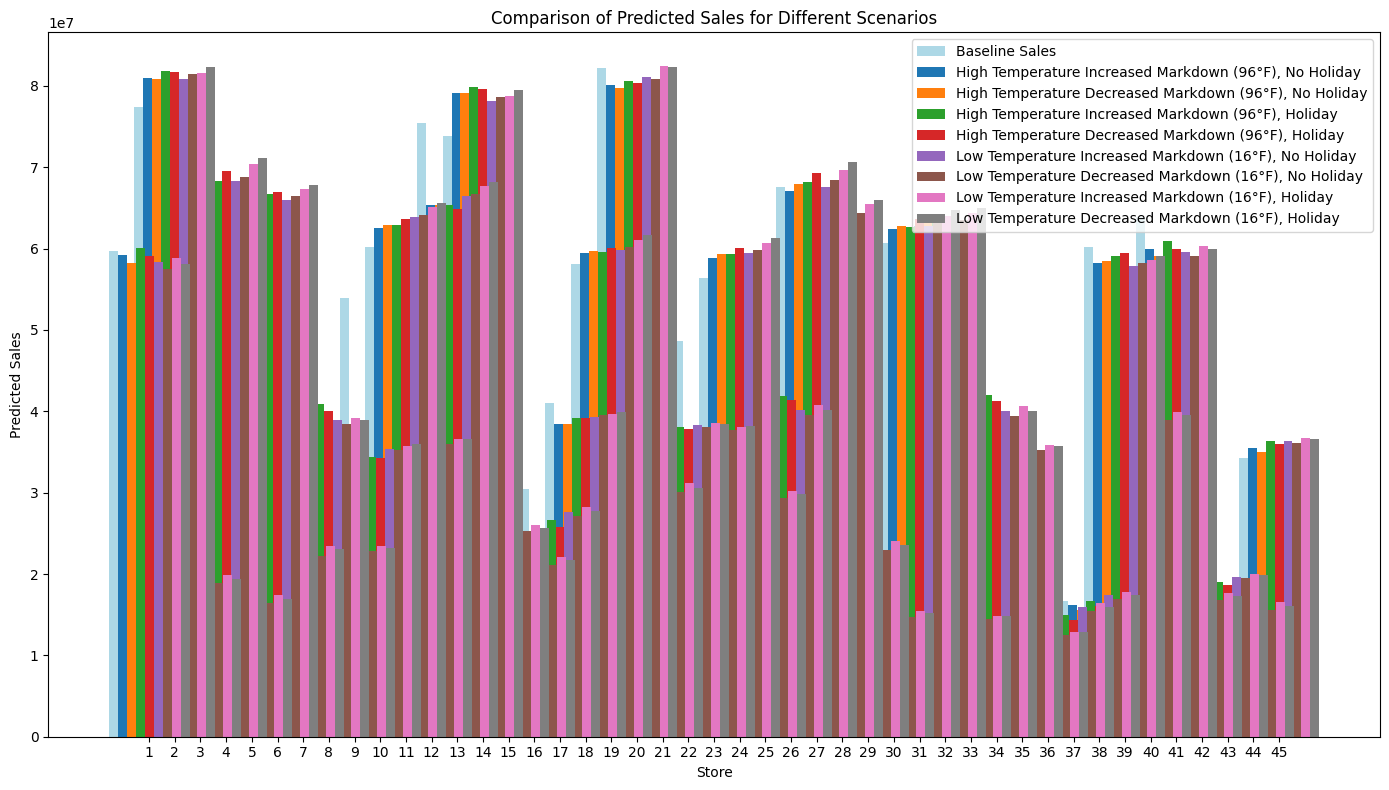

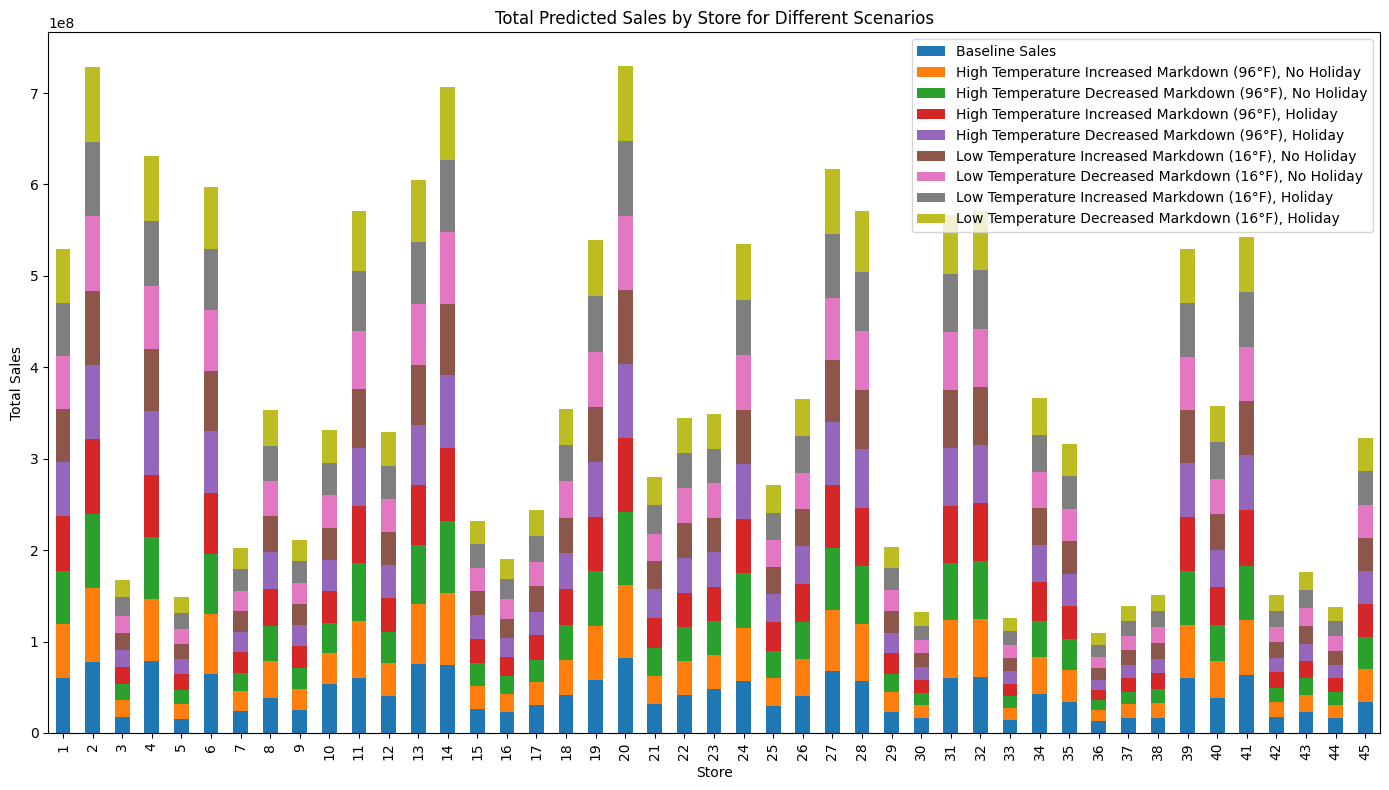


Store-level scenario results saved to 'store_level_scenario_results.csv'


In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Assuming df_test_merged, lgb_model, and selected_features are preloaded

# Define scenarios with the first two retained and CPI applied
scenarios = [
    {"scenario": "High Temperature Increased Markdown (96°F), No Holiday", "markdown_factor": 1.5, "temperature": 96, "holiday": False, "fuel_price": None, "unemployment": None, "cpi": None},
    {"scenario": "High Temperature Decreased Markdown (96°F), No Holiday", "markdown_factor": 0.5, "temperature": 96, "holiday": False, "fuel_price": None, "unemployment": None, "cpi": None},
    {"scenario": "High Temperature Increased Markdown (96°F), Holiday", "markdown_factor": 1.5, "temperature": 96, "holiday": True, "fuel_price": None, "unemployment": None, "cpi": None},
    {"scenario": "High Temperature Decreased Markdown (96°F), Holiday", "markdown_factor": 0.5, "temperature": 96, "holiday": True, "fuel_price": None, "unemployment": None, "cpi": None},
    {"scenario": "Low Temperature Increased Markdown (16°F), No Holiday", "markdown_factor": 1.5, "temperature": 16, "holiday": False, "fuel_price": None, "unemployment": None, "cpi": None},
    {"scenario": "Low Temperature Decreased Markdown (16°F), No Holiday", "markdown_factor": 0.5, "temperature": 16, "holiday": False, "fuel_price": None, "unemployment": None, "cpi": None},
    {"scenario": "Low Temperature Increased Markdown (16°F), Holiday", "markdown_factor": 1.5, "temperature": 16, "holiday": True, "fuel_price": None, "unemployment": None, "cpi": None},
    {"scenario": "Low Temperature Decreased Markdown (16°F), Holiday", "markdown_factor": 0.5, "temperature": 16, "holiday": True, "fuel_price": None, "unemployment": None, "cpi": None},
]

# Function to apply scenario conditions and handle variables
def apply_scenario(test_data, scenario):
    test_data = test_data.copy()
    markdown_cols = ['markdown1', 'markdown3', 'markdown5']
    
    # Adjust markdowns based on markdown_factor
    markdown_factor = scenario.get("markdown_factor", 1.0)
    for col in markdown_cols:
        test_data[col] *= markdown_factor
    
    # Handle temperature adjustments
    if scenario.get("temperature") is not None:
        test_data['temperature'] = scenario['temperature']
    else:
        # If temperature is None, use median temperature
        median_temp = test_data['temperature'].median()
        test_data['temperature'] = median_temp
    
    # Handle holiday adjustments
    if scenario.get("holiday") is not None:
        test_data['IsHoliday'] = scenario['holiday']
    else:
        # If holiday is None, use mode of the holiday status
        mode_holiday = test_data['IsHoliday'].mode()[0]
        test_data['IsHoliday'] = mode_holiday

    # Handle CPI adjustments
    if scenario.get("cpi") is not None:
        test_data['cpi'] = scenario['cpi']
    else:
        # If CPI is None, use median CPI
        median_cpi = test_data['cpi'].median()
        test_data['cpi'] = median_cpi
    
    # Handle unemployment adjustments
    if scenario.get("unemployment") is not None:
        test_data['unemployment'] = scenario['unemployment']
    else:
        # If unemployment is None, use median unemployment
        median_unemployment = test_data['unemployment'].median()
        test_data['unemployment'] = median_unemployment
    
    # Handle fuel price: Replace with scenario value if provided, else use the median value
    if scenario.get("fuel_price") is not None:
        test_data['fuel_price'] = scenario['fuel_price']
    else:
        # Replace with median if 'fuel_price' is None
        median_fuel_price = test_data['fuel_price'].median()
        test_data['fuel_price'] = median_fuel_price
    
    return test_data

# Baseline prediction
baseline_data = df_test_merged.copy()
baseline_data['predicted_sales'] = lgb_model.predict(baseline_data[selected_features])
baseline_store_sales = baseline_data.groupby('store')['predicted_sales'].sum().reset_index()
baseline_store_sales.rename(columns={'predicted_sales': 'Baseline Sales'}, inplace=True)

# Analyze each scenario
store_results = baseline_store_sales.copy()

# Apply all scenarios
for scenario in scenarios:
    print(f"\nApplying scenario: {scenario['scenario']}")
    test_data = apply_scenario(df_test_merged, scenario)
    
    # Predict sales based on the scenario
    test_data['predicted_sales'] = lgb_model.predict(test_data[selected_features])
    
    # Aggregating sales by store for this scenario
    scenario_sales = test_data.groupby('store')['predicted_sales'].sum().reset_index()
    
    # Ensure the scenario name is used as the column name
    scenario_sales.rename(columns={'predicted_sales': scenario['scenario']}, inplace=True)
    
    # Merge the scenario sales into the store_results DataFrame
    store_results = pd.merge(store_results, scenario_sales, on='store', how='left')

# Calculate total sales percentage change for each scenario
total_sales_changes = {}
for scenario in scenarios:
    scenario_name = scenario['scenario']
    baseline_total = store_results['Baseline Sales'].sum()
    scenario_total = store_results[scenario_name].sum()
    percentage_change = ((scenario_total - baseline_total) / baseline_total) * 100
    total_sales_changes[scenario_name] = percentage_change

# Display total sales percentage change
print("\n==================== Change in Total Sales Percentage for Each Scenario ====================")
for scenario, change in total_sales_changes.items():
    print(f"{scenario}: {change:.2f}%")

# Visualization of the predicted sales for each scenario

# Bar Plot - Side by Side Comparison of Baseline vs Predicted Sales for each Scenario
fig, ax = plt.subplots(figsize=(14, 8))

# Set the bar width
bar_width = 0.35
index = np.arange(len(store_results))

# Plot baseline sales and predicted sales for each scenario
ax.bar(index, store_results['Baseline Sales'], bar_width, label='Baseline Sales', color='lightblue')
for i, scenario in enumerate(scenarios):
    ax.bar(index + (i + 1) * bar_width, store_results[scenario['scenario']], bar_width, label=scenario['scenario'])

# Adding labels and title
ax.set_xlabel('Store')
ax.set_ylabel('Predicted Sales')
ax.set_title('Comparison of Predicted Sales for Different Scenarios')
ax.set_xticks(index + bar_width * (len(scenarios) / 2))
ax.set_xticklabels(store_results['store'])
ax.legend()

plt.tight_layout()
plt.show()

# Stacked Bar Chart - Total Predicted Sales Contribution by Scenario
fig, ax = plt.subplots(figsize=(14, 8))

# Plot stacked bars for each store
store_results.set_index('store')[['Baseline Sales'] + [scenario['scenario'] for scenario in scenarios]].plot(kind='bar', stacked=True, ax=ax)

# Adding labels and title
ax.set_xlabel('Store')
ax.set_ylabel('Total Sales')
ax.set_title('Total Predicted Sales by Store for Different Scenarios')

plt.tight_layout()
plt.show()
# Save the results for all scenarios
store_results.to_csv("store_level_scenario_results.csv", index=False)
print("\nStore-level scenario results saved to 'store_level_scenario_results.csv'")


### Change the default values to minimum


Applying scenario: High Temperature Increased Markdown (96°F), No Holiday
CPI is None, replacing with minimum: 131.2362258
Unemployment is None, replacing with minimum: 3.684
Fuel Price is None, replacing with minimum: 2.872

Applying scenario: High Temperature Decreased Markdown (96°F), No Holiday
CPI is None, replacing with minimum: 131.2362258
Unemployment is None, replacing with minimum: 3.684
Fuel Price is None, replacing with minimum: 2.872

Applying scenario: High Temperature Increased Markdown (96°F), Holiday
CPI is None, replacing with minimum: 131.2362258
Unemployment is None, replacing with minimum: 3.684
Fuel Price is None, replacing with minimum: 2.872

Applying scenario: High Temperature Decreased Markdown (96°F), Holiday
CPI is None, replacing with minimum: 131.2362258
Unemployment is None, replacing with minimum: 3.684
Fuel Price is None, replacing with minimum: 2.872

Applying scenario: Low Temperature Increased Markdown (16°F), No Holiday
CPI is None, replacing with 

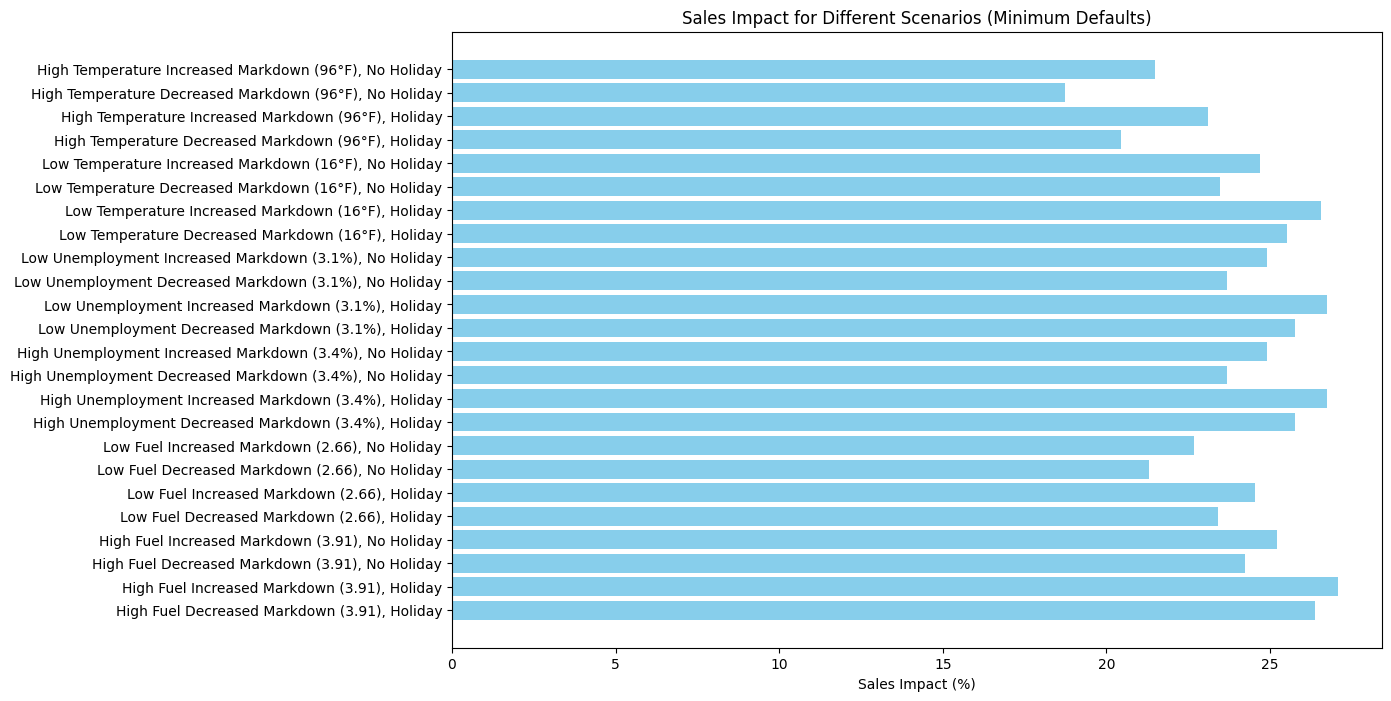

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# Function to apply scenario conditions and handle variables with defaults set to minimum

def apply_scenario(test_data, scenario):
    test_data = test_data.copy()
    markdown_cols = ['markdown1', 'markdown3', 'markdown5']

    # Adjust markdowns
    markdown_factor = scenario.get("markdown_factor", 1.0)
    for col in markdown_cols:
        test_data[col] *= markdown_factor

    # Adjust temperature: Use minimum if not provided
    if scenario.get("temperature") is not None:
        test_data['temperature'] = scenario['temperature']
    else:
        min_temp = test_data['temperature'].min()
        print(f"Temperature is None, replacing with minimum: {min_temp}")
        test_data['temperature'] = min_temp

    test_data['temperature'] = test_data['temperature'].apply(lambda x: max(x, 0))  # Replace negatives with 0

    # Adjust holiday status: Use minimum (False) if not provided
    if scenario.get("holiday") is not None:
        test_data['IsHoliday'] = scenario['holiday']
    else:
        print("Holiday is None, replacing with minimum: False")
        test_data['IsHoliday'] = False

    # Adjust CPI: Use minimum if not provided
    if scenario.get("cpi") is not None:
        test_data['cpi'] = scenario['cpi']
    else:
        min_cpi = test_data['cpi'].min()
        print(f"CPI is None, replacing with minimum: {min_cpi}")
        test_data['cpi'] = min_cpi

    # Adjust unemployment: Use minimum if not provided
    if scenario.get("unemployment") is not None:
        test_data['unemployment'] = scenario['unemployment']
    else:
        min_unemployment = test_data['unemployment'].min()
        print(f"Unemployment is None, replacing with minimum: {min_unemployment}")
        test_data['unemployment'] = min_unemployment

    # Adjust fuel price: Use minimum if not provided
    if scenario.get("fuel_price") is not None:
        test_data['fuel_price'] = scenario['fuel_price']
    else:
        min_fuel_price = test_data['fuel_price'].min()
        print(f"Fuel Price is None, replacing with minimum: {min_fuel_price}")
        test_data['fuel_price'] = min_fuel_price

    return test_data

# Baseline prediction
baseline_data = df_test_merged.copy()
baseline_data['predicted_sales'] = lgb_model.predict(baseline_data[selected_features])
baseline_total_sales = baseline_data['predicted_sales'].sum()

# Scenario analysis
results = []
for scenario in scenarios:
    scenario_name = scenario['scenario']
    print(f"\nApplying scenario: {scenario_name}")
    scenario_data = apply_scenario(df_test_merged, scenario)
    scenario_data['predicted_sales'] = lgb_model.predict(scenario_data[selected_features])
    scenario_total_sales = scenario_data['predicted_sales'].sum()

    sales_change = ((scenario_total_sales - baseline_total_sales) / baseline_total_sales) * 100
    results.append({
        "Scenario": scenario_name,
        "Markdown Factor": scenario.get("markdown_factor", 1.0),
        "Temperature/Fuel Price/Unemployment": scenario.get("temperature", scenario.get("fuel_price", scenario.get("unemployment", "N/A"))),
        "Holiday": scenario.get("holiday", "N/A"),
        "Sales Impact (%)": sales_change
    })

# Create a DataFrame for results
results_df = pd.DataFrame(results)

# Display results
print(results_df)

# Save results to CSV
results_df.to_csv("scenario_sales_impact_minimum_defaults.csv", index=False)

# Plot the results
plt.figure(figsize=(12, 8))
plt.barh(results_df['Scenario'], results_df['Sales Impact (%)'], color='skyblue')
plt.xlabel('Sales Impact (%)')
plt.title('Sales Impact for Different Scenarios (Minimum Defaults)')
plt.gca().invert_yaxis()
plt.show()


### Change the default values to max


Applying scenario: High Temperature Increased Markdown (96°F), No Holiday
CPI is None, replacing with maximum: 228.9764563
Unemployment is None, replacing with maximum: 10.199
Fuel Price is None, replacing with maximum: 4.125

Applying scenario: High Temperature Decreased Markdown (96°F), No Holiday
CPI is None, replacing with maximum: 228.9764563
Unemployment is None, replacing with maximum: 10.199
Fuel Price is None, replacing with maximum: 4.125

Applying scenario: High Temperature Increased Markdown (96°F), Holiday
CPI is None, replacing with maximum: 228.9764563
Unemployment is None, replacing with maximum: 10.199
Fuel Price is None, replacing with maximum: 4.125

Applying scenario: High Temperature Decreased Markdown (96°F), Holiday
CPI is None, replacing with maximum: 228.9764563
Unemployment is None, replacing with maximum: 10.199
Fuel Price is None, replacing with maximum: 4.125

Applying scenario: Low Temperature Increased Markdown (16°F), No Holiday
CPI is None, replacing w

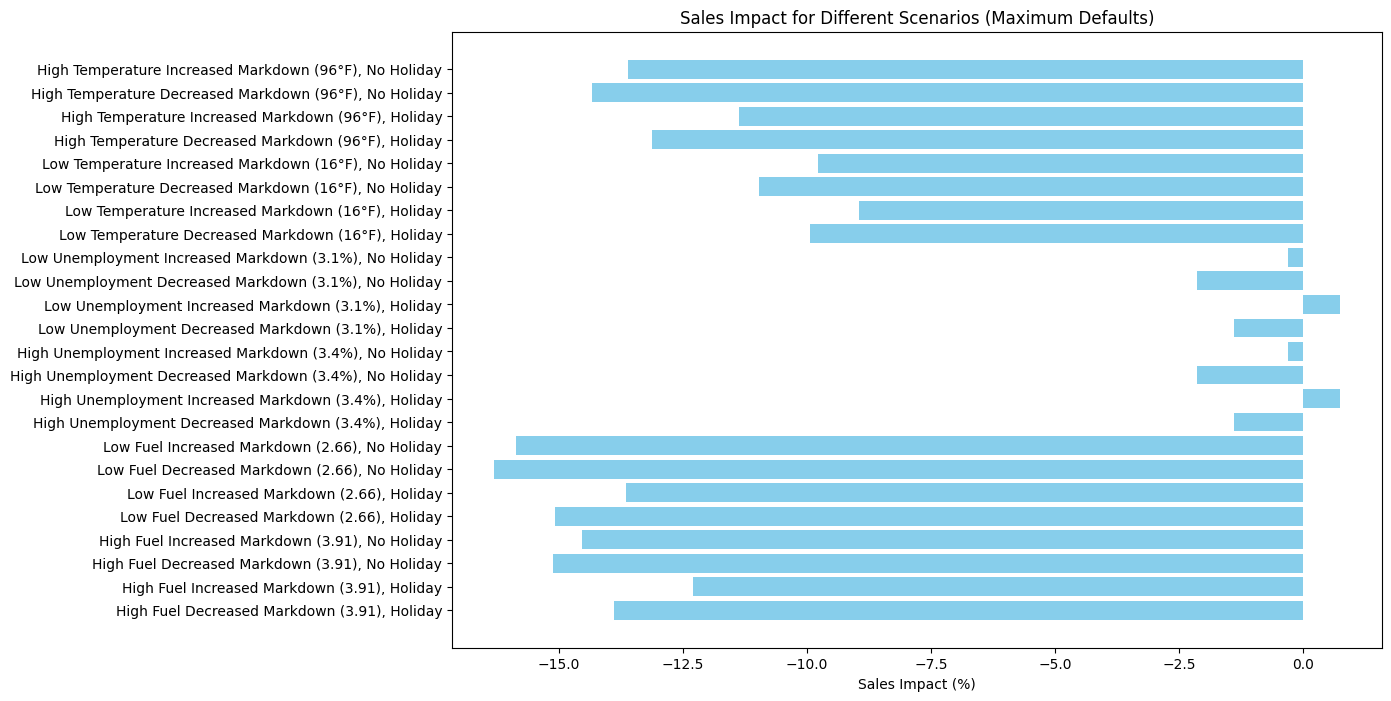

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# Function to apply scenario conditions and handle variables with defaults set to maximum

def apply_scenario(test_data, scenario):
    test_data = test_data.copy()
    markdown_cols = ['markdown1', 'markdown3', 'markdown5']

    # Adjust markdowns
    markdown_factor = scenario.get("markdown_factor", 1.0)
    for col in markdown_cols:
        test_data[col] *= markdown_factor

    # Adjust temperature: Use maximum if not provided
    if scenario.get("temperature") is not None:
        test_data['temperature'] = scenario['temperature']
    else:
        max_temp = test_data['temperature'].max()
        print(f"Temperature is None, replacing with maximum: {max_temp}")
        test_data['temperature'] = max_temp

    test_data['temperature'] = test_data['temperature'].apply(lambda x: max(x, 0))  # Replace negatives with 0

    # Adjust holiday status: Use maximum (True) if not provided
    if scenario.get("holiday") is not None:
        test_data['IsHoliday'] = scenario['holiday']
    else:
        print("Holiday is None, replacing with maximum: True")
        test_data['IsHoliday'] = True

    # Adjust CPI: Use maximum if not provided
    if scenario.get("cpi") is not None:
        test_data['cpi'] = scenario['cpi']
    else:
        max_cpi = test_data['cpi'].max()
        print(f"CPI is None, replacing with maximum: {max_cpi}")
        test_data['cpi'] = max_cpi

    # Adjust unemployment: Use maximum if not provided
    if scenario.get("unemployment") is not None:
        test_data['unemployment'] = scenario['unemployment']
    else:
        max_unemployment = test_data['unemployment'].max()
        print(f"Unemployment is None, replacing with maximum: {max_unemployment}")
        test_data['unemployment'] = max_unemployment

    # Adjust fuel price: Use maximum if not provided
    if scenario.get("fuel_price") is not None:
        test_data['fuel_price'] = scenario['fuel_price']
    else:
        max_fuel_price = test_data['fuel_price'].max()
        print(f"Fuel Price is None, replacing with maximum: {max_fuel_price}")
        test_data['fuel_price'] = max_fuel_price

    return test_data

# Baseline prediction
baseline_data = df_test_merged.copy()
baseline_data['predicted_sales'] = lgb_model.predict(baseline_data[selected_features])
baseline_total_sales = baseline_data['predicted_sales'].sum()

# Scenario analysis
results = []
for scenario in scenarios:
    scenario_name = scenario['scenario']
    print(f"\nApplying scenario: {scenario_name}")
    scenario_data = apply_scenario(df_test_merged, scenario)
    scenario_data['predicted_sales'] = lgb_model.predict(scenario_data[selected_features])
    scenario_total_sales = scenario_data['predicted_sales'].sum()

    sales_change = ((scenario_total_sales - baseline_total_sales) / baseline_total_sales) * 100
    results.append({
        "Scenario": scenario_name,
        "Markdown Factor": scenario.get("markdown_factor", 1.0),
        "Temperature/Fuel Price/Unemployment": scenario.get("temperature", scenario.get("fuel_price", scenario.get("unemployment", "N/A"))),
        "Holiday": scenario.get("holiday", "N/A"),
        "Sales Impact (%)": sales_change
    })

# Create a DataFrame for results
results_df = pd.DataFrame(results)

# Display results
print(results_df)

# Save results to CSV
results_df.to_csv("scenario_sales_impact_maximum_defaults.csv", index=False)

# Plot the results
plt.figure(figsize=(12, 8))
plt.barh(results_df['Scenario'], results_df['Sales Impact (%)'], color='skyblue')
plt.xlabel('Sales Impact (%)')
plt.title('Sales Impact for Different Scenarios (Maximum Defaults)')
plt.gca().invert_yaxis()
plt.show()
